# E2 Dynamical Misspecification


In [1]:
import importlib
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing src/.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS_ROOT = ROOT / "outputs"
print("Project root:", ROOT)
print("Outputs root:", OUTPUTS_ROOT)

import numpy as np
import pandas as pd
from IPython.display import display

from src.config import (
    get_e2_curve_level_output_dir,
    get_e2_curve_level_tau_output_dir,
    get_e2_reference_sensitivity_output_dir,
    get_e2_severity_output_dir,
    get_e2_severity_summary_output_dir,
    setup_environment,
)
from src.diagnostics import evaluate_curve_level_ppc
from src.experiments import (
    build_E2_reference_sensitivity_summary,
    build_E2_severity_summary,
    build_E2_severity_summary_with_uncertainty,
    run_E2_evaluation,
    run_extended_E2_feature_evaluation,
)
from src.plotting import (
    plot_E2_reference_sensitivity,
    plot_E2_severity_3panel_summary,
    plot_E2_severity_single_line,
    plot_curve_level_ppc_summary,
    plot_e2_example_case,
    plot_e2_overall_figure,
    plot_feature_residuals,
)
from src.simulators import beta_t_piecewise, simulate_case_E2, simulate_curve
from src.workflow import train_workflow


Project root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project
Outputs root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project/outputs


In [2]:
missing = []
for pkg in ["bayesflow", "tensorflow", "keras"]:
    try:
        importlib.import_module(pkg)
        print(f"[ok] {pkg}")
    except Exception as e:
        missing.append(pkg)
        print(f"[missing] {pkg}: {e}")

if missing:
    print("\nInstall missing packages in the current kernel environment, for example:")
    print("python -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn")
else:
    print("\nBackend check passed.")


INFO:bayesflow:Using backend 'tensorflow'


[ok] bayesflow
[ok] tensorflow
[ok] keras

Backend check passed.


In [3]:
# Optional install cell.
# Uncomment and run this cell if the backend packages are missing,
# then restart the kernel before re-running the notebook.

import sys
print(sys.executable)
# !{sys.executable} -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn


/opt/anaconda3/envs/bayesflow311/bin/python


In [4]:
setup_environment(seed=42)
workflow_E0, history_E0 = train_workflow(seed=42)


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


bayesflow: 2.0.7
tensorflow: 2.17.0
keras: 3.9.0
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4
Epoch 1/12
60/60 - 15s - 244ms/step - loss: 2.5441
Epoch 2/12
60/60 - 3s - 58ms/step - loss: 1.4825
Epoch 3/12
60/60 - 3s - 50ms/step - loss: 0.9436
Epoch 4/12
60/60 - 3s - 50ms/step - loss: 0.4041
Epoch 5/12
60/60 - 3s - 51ms/step - loss: 0.1514
Epoch 6/12
60/60 - 3s - 50ms/step - loss: -1.6706e-01
Epoch 7/12
60/60 - 3s - 50ms/step - loss: -4.1431e-01
Epoch 8/12
60/60 - 3s - 50ms/step - loss: -5.3902e-01
Epoch 9/12
60/60 - 3s - 50ms/step - loss: -7.0491e-01
Epoch 10/12
60/60 - 3s - 50ms/step - loss: -8.0065e-01
Epoch 11/12
60/60 - 3s - 51ms/step - loss: -8.9503e-01
Epoch 12/12
60/60 - 3s - 57ms/step - loss: -9.4798e-01


# E2: dynamical misspecification, test-only time-varying beta(t) misspecification


1. 证明错配来自 transmission dynamics，而不是 observation noise
2. 错配强度可以通过 kappa 连续控制
3. 单个 strong case 是否显示出明显的 transmission shift


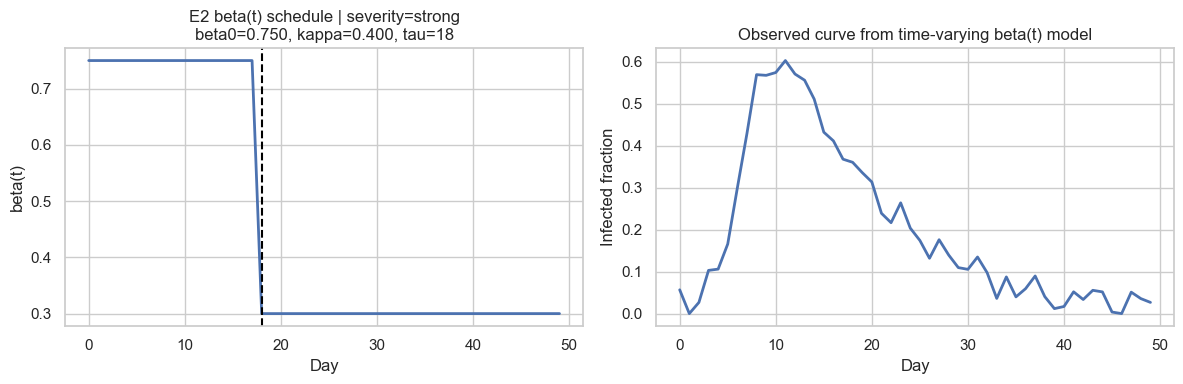

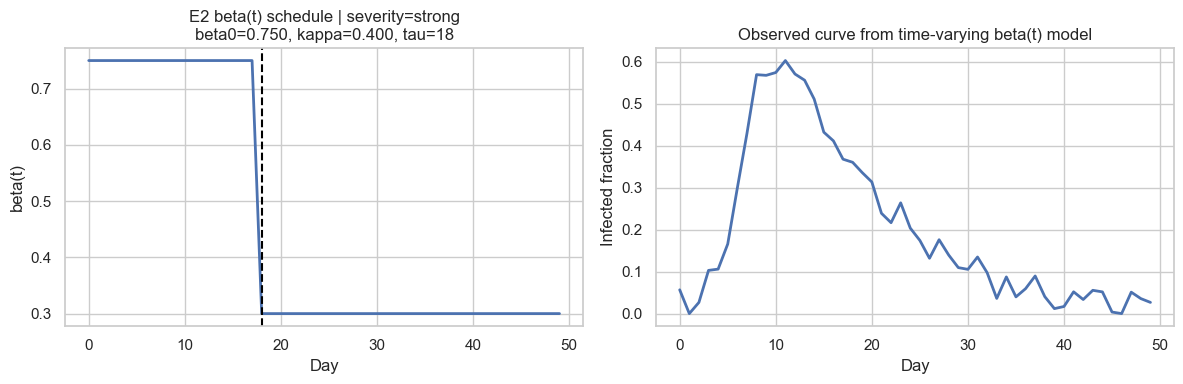

In [5]:
# Example: visualize one E2 case

example_rng = np.random.default_rng(3030)
example_case_E2 = simulate_case_E2(
    rng=example_rng,
    severity="strong",
    beta0=0.75,
    gamma=0.10,
    tau=18,
    kappa=0.40,
)
example_beta_path = beta_t_piecewise(
    np.arange(len(example_case_E2["obs"])),
    beta0=example_case_E2["beta0"],
    tau=example_case_E2["tau"],
    kappa=example_case_E2["kappa"],
)
plot_e2_example_case(
    example_case_E2,
    np.arange(len(example_beta_path)),
    example_beta_path,
    out_path=str(OUTPUTS_ROOT / "E2" / "E2_example_case.png"),
)


To instantiate E2, we keep the inference model fixed to the matched constant-β SIR setup used in E0, but generate test observations from a piecewise time-varying transmission process. Specifically, β(t) starts at a baseline value β0 and then drops at a random change point τ by a multiplicative factor κ. The posterior amortizer is not retrained under this new data-generating mechanism: it still assumes constant β. Therefore, any degradation we observe comes from a dynamical misspecification in the latent epidemic process rather than from a change in noise model or optimization setup.


In [6]:
# mild / medium / strong

severity_outputs = {}
for severity in ["mild", "medium", "strong"]:
    case_df_E2, recovery_df_E2, coverage_df_E2, feature_case_df_E2, feature_summary_df_E2 = run_E2_evaluation(
        workflow=workflow_E0,
        severity=severity,
        beta_ref_mode="time_avg",
        n_test=100,
        num_posterior_samples=2000,
        n_ppc_draws=100,
        seed=2027,
    )
    severity_outputs[severity] = {
        "case_df": case_df_E2,
        "recovery_df": recovery_df_E2,
        "coverage_df": coverage_df_E2,
        "feature_case_df": feature_case_df_E2,
        "feature_summary_df": feature_summary_df_E2,
    }

    out_dir = OUTPUTS_ROOT / "E2" / severity
    out_dir.mkdir(parents=True, exist_ok=True)
    case_df_E2.to_csv(out_dir / "E2_case_level.csv", index=False)
    recovery_df_E2.to_csv(out_dir / "E2_recovery_summary.csv", index=False)
    coverage_df_E2.to_csv(out_dir / "E2_coverage_summary.csv", index=False)
    feature_case_df_E2.to_csv(out_dir / "E2_ppc_feature_case_level.csv", index=False)
    feature_summary_df_E2.to_csv(out_dir / "E2_ppc_feature_summary.csv", index=False)


In [7]:
severity_to_run = "mild"
case_df_E2 = severity_outputs[severity_to_run]["case_df"]
mild_recovery_df_E2 = severity_outputs[severity_to_run]["recovery_df"]
mild_coverage_df_E2 = severity_outputs[severity_to_run]["coverage_df"]
feature_case_df_E2 = severity_outputs[severity_to_run]["feature_case_df"]
mild_feature_summary_df_E2 = severity_outputs[severity_to_run]["feature_summary_df"]

display(case_df_E2.head())
display(mild_recovery_df_E2.round(4))
display(mild_coverage_df_E2.round(4))
display(mild_feature_summary_df_E2.round(4))


,case_id,true_beta,true_gamma,true_R0,true_beta_timeavg,true_beta_infweighted,true_R0_timeavg,true_R0_infweighted,beta_ref_mode,beta0,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.101553,0.223647,0.454077,0.101553,0.105916,0.454077,0.473583,time_avg,0.107205,...,0.104811,0.115740,0.115740,1.339585e-02,0.0,1.0,0.311190,0.317497,0.317497,0.100804
1,1,0.680205,0.142269,4.781116,0.680205,0.682432,4.781116,4.796772,time_avg,0.702721,...,0.000336,0.000246,0.000246,6.027523e-08,1.0,1.0,0.031355,0.030860,0.030860,0.000952
2,2,0.505587,0.100655,5.022946,0.505587,0.501064,5.022946,4.978015,time_avg,0.565901,...,0.001273,0.001048,0.001048,1.098433e-06,0.0,0.0,0.451658,0.437615,0.437615,0.191507
3,3,0.125957,0.458047,0.274986,0.125957,0.132910,0.274986,0.290166,time_avg,0.132926,...,-0.121211,-0.100576,0.100576,1.011554e-02,0.0,0.0,0.498525,0.484411,0.484411,0.234654
4,4,0.750525,0.338086,2.219919,0.750525,0.792771,2.219919,2.344876,time_avg,0.797830,...,-0.004705,-0.005731,0.005731,3.284739e-05,0.0,0.0,0.167119,0.164392,0.164392,0.027025


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.0325,0.0298,0.0548,0.0698,0.9694,0.0544
1,gamma,-0.0037,0.0017,0.0341,0.0567,0.9019,0.0414
2,R0,0.0933,0.0894,0.1632,0.2284,0.9965,0.2342


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.30,-0.20,0.9,0.78,-0.12,0.0754,0.1751
1,gamma,0.5,0.48,-0.02,0.9,0.96,0.06,0.0594,0.1337
2,R0,0.5,0.46,-0.04,0.9,0.82,-0.08,0.2979,0.7298


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.63,0.13,0.9,0.93,0.03,-1.0915,-1.5850,5.1950,8.6884,6.5361,10.1975,19.8670
1,peak_height,0.5,0.62,0.12,0.9,0.96,0.06,-0.0022,-0.0030,0.0113,0.0153,0.0199,0.0252,0.0629
2,cumulative_infected,0.5,0.77,0.27,0.9,0.99,0.09,-0.0192,-0.0378,0.1380,0.2036,0.3656,0.4433,1.1045
3,early_growth_slope,0.5,0.45,-0.05,0.9,0.94,0.04,-0.0010,-0.0009,0.0025,0.0031,0.0034,0.0045,0.0111


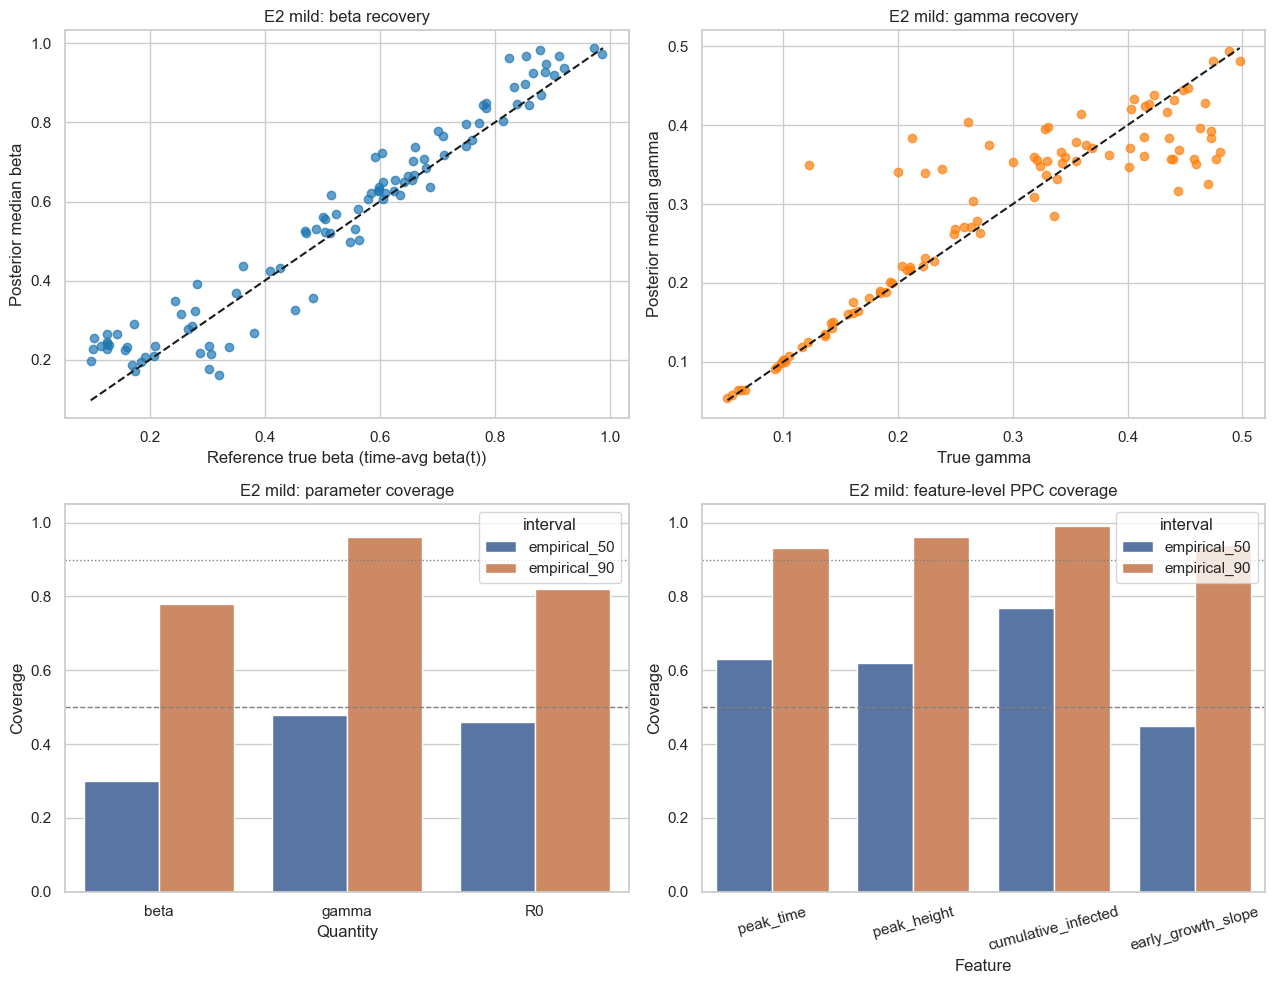

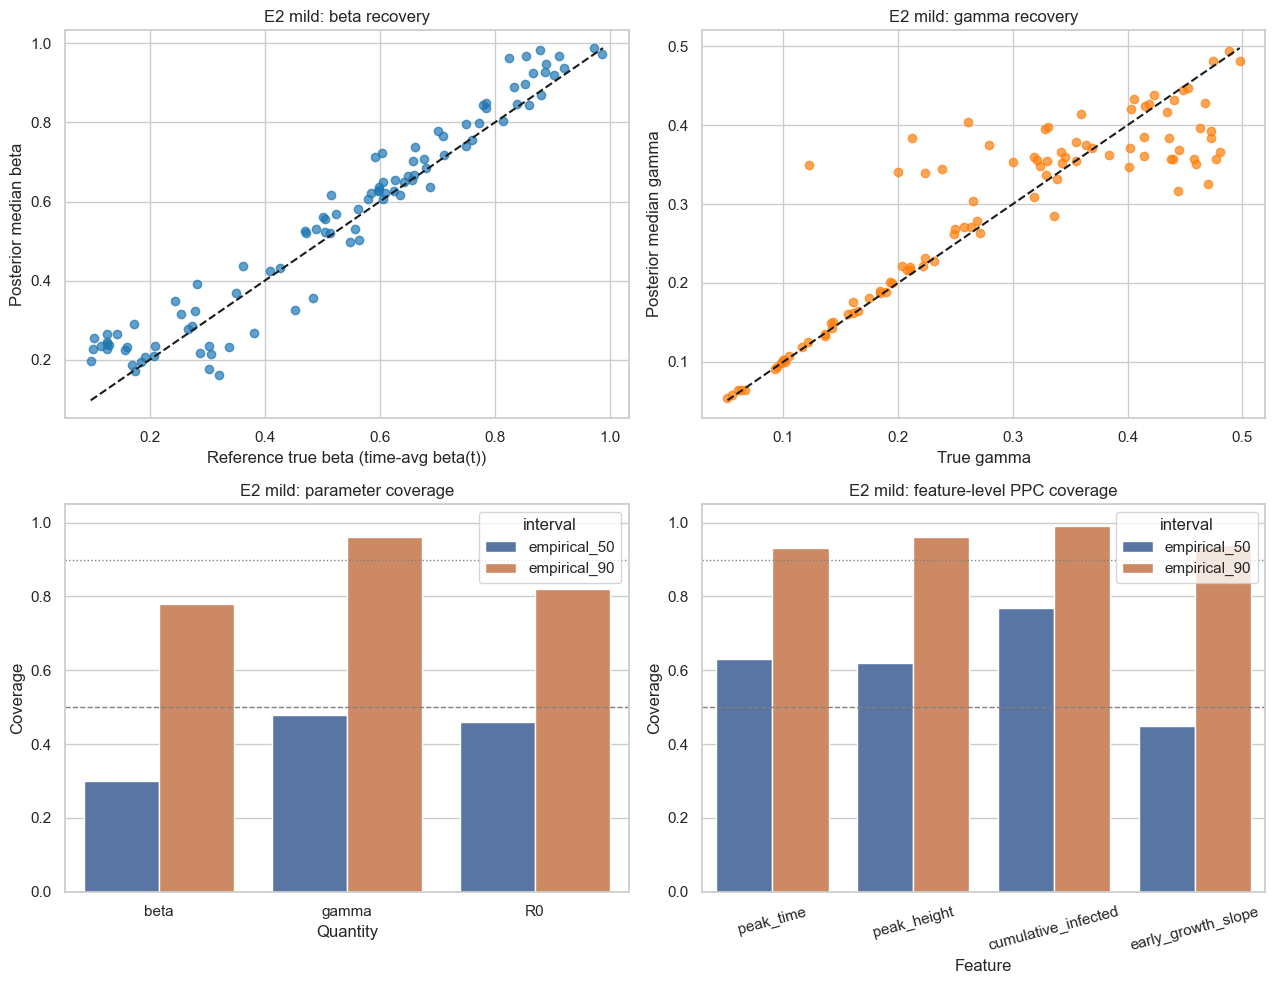

In [8]:
plot_e2_overall_figure(
    case_df_E2,
    mild_coverage_df_E2,
    mild_feature_summary_df_E2,
    severity_label="mild",
    out_path=str(OUTPUTS_ROOT / "E2" / "mild" / "E2_overall_figure.png"),
)


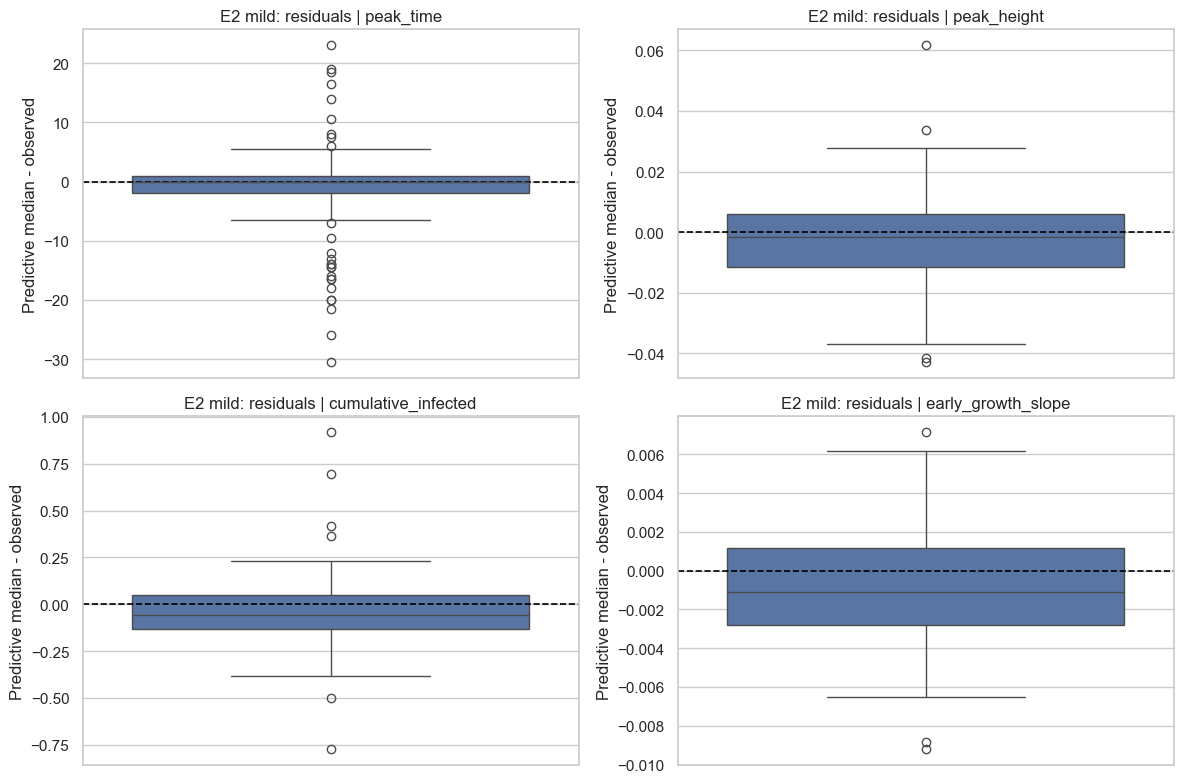

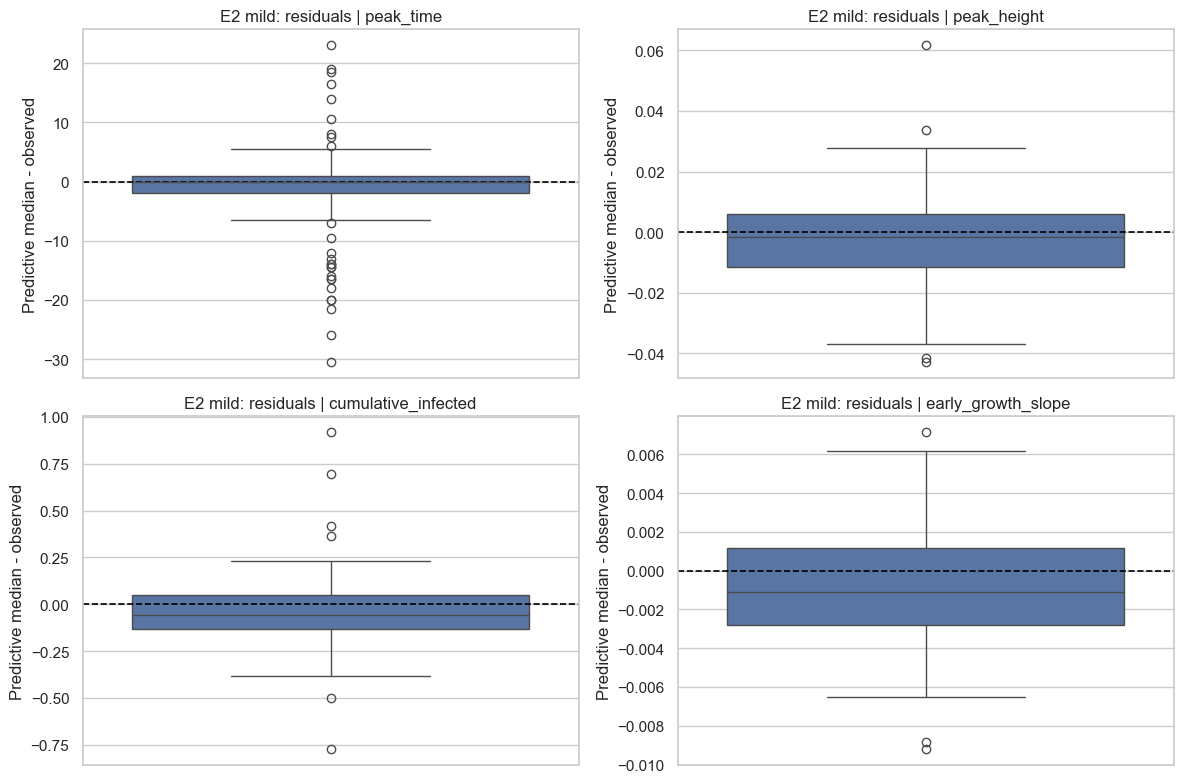

In [9]:
plot_feature_residuals(
    feature_case_df_E2,
    title_prefix="E2 mild",
)


mild结论：
1. 在 mild misspecification 下，posterior recovery 整体仍保持较高相关性，说明 constant-β amortizer 还没有完全失去恢复能力。
2. beta 的 empirical coverage 已经明显低于 nominal，表明 transmission-related posterior calibration 是最先退化的部分。
3. feature-level PPC 仍然看起来不差，说明低维 predictive adequacy 可能掩盖 posterior 层面的失真。


In [10]:
severity_to_run = "medium"
case_df_E2 = severity_outputs[severity_to_run]["case_df"]
medium_recovery_df_E2 = severity_outputs[severity_to_run]["recovery_df"]
medium_coverage_df_E2 = severity_outputs[severity_to_run]["coverage_df"]
feature_case_df_E2 = severity_outputs[severity_to_run]["feature_case_df"]
medium_feature_summary_df_E2 = severity_outputs[severity_to_run]["feature_summary_df"]

display(case_df_E2.head())
display(medium_recovery_df_E2.round(4))
display(medium_coverage_df_E2.round(4))
display(medium_feature_summary_df_E2.round(4))


,case_id,true_beta,true_gamma,true_R0,true_beta_timeavg,true_beta_infweighted,true_R0_timeavg,true_R0_infweighted,beta_ref_mode,beta0,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.086529,0.223647,0.386898,0.086529,0.103008,0.386898,0.460581,time_avg,0.107205,...,0.108174,0.121759,0.121759,1.482537e-02,0.0,0.0,0.370449,0.373404,0.373404,0.139431
1,1,0.582976,0.142269,4.097702,0.582976,0.595167,4.097702,4.183387,time_avg,0.702721,...,0.000691,0.000444,0.000444,1.968955e-07,0.0,0.0,0.707778,0.700921,0.700921,0.491290
2,2,0.399167,0.100655,3.965676,0.399167,0.387388,3.965676,3.848651,time_avg,0.565901,...,0.001186,0.001092,0.001092,1.191852e-06,0.0,0.0,1.474993,1.462480,1.462480,2.138847
3,3,0.109347,0.458047,0.238725,0.109347,0.132875,0.238725,0.290091,time_avg,0.132926,...,-0.118526,-0.099366,0.099366,9.873677e-03,0.0,0.0,0.536903,0.523999,0.523999,0.274575
4,4,0.651970,0.338086,1.928411,0.651970,0.783332,1.928411,2.316957,time_avg,0.797830,...,-0.004355,-0.005107,0.005107,2.608299e-05,0.0,0.0,0.457612,0.451610,0.451610,0.203952


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.1075,0.1049,0.1177,0.1334,0.9494,0.0562
1,gamma,0.0033,0.0089,0.0401,0.0625,0.8825,0.0419
2,R0,0.4040,0.3996,0.4111,0.5406,0.9950,0.2290


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.17,-0.33,0.9,0.31,-0.59,0.0779,0.1804
1,gamma,0.5,0.42,-0.08,0.9,0.78,-0.12,0.0604,0.1349
2,R0,0.5,0.16,-0.34,0.9,0.36,-0.54,0.2965,0.7254


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.61,0.11,0.9,0.92,0.02,-0.4653,-1.0350,5.3650,8.6783,6.6520,10.2475,20.3980
1,peak_height,0.5,0.56,0.06,0.9,0.94,0.04,-0.0019,-0.0029,0.0116,0.0162,0.0190,0.0239,0.0598
2,cumulative_infected,0.5,0.73,0.23,0.9,0.99,0.09,0.0084,-0.0121,0.1398,0.2187,0.3367,0.4027,1.0537
3,early_growth_slope,0.5,0.39,-0.11,0.9,0.93,0.03,-0.0010,-0.0010,0.0027,0.0033,0.0034,0.0045,0.0110


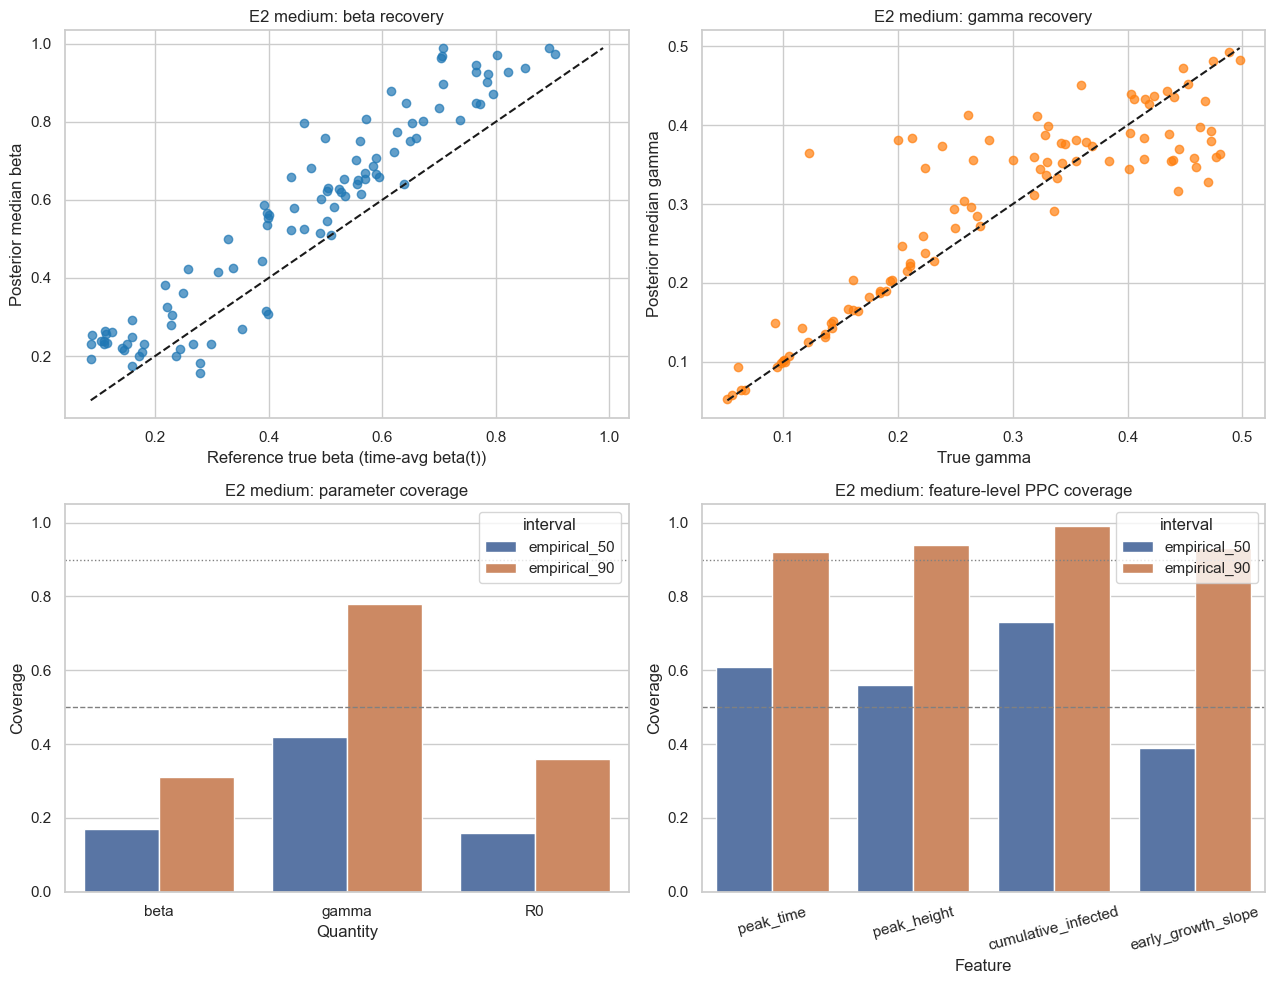

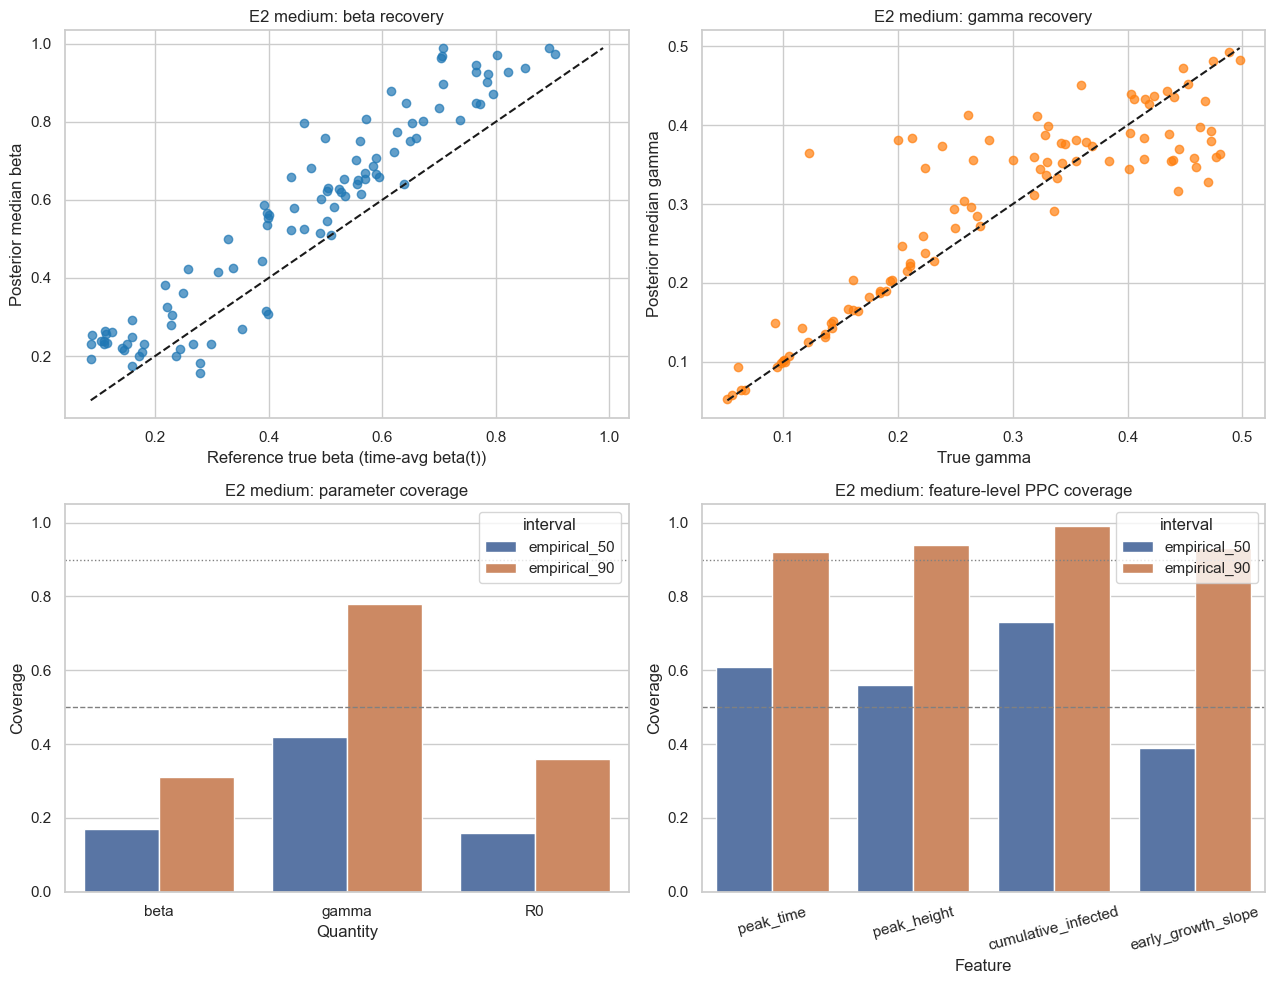

In [11]:
plot_e2_overall_figure(
    case_df_E2,
    medium_coverage_df_E2,
    medium_feature_summary_df_E2,
    severity_label="medium",
    out_path=str(OUTPUTS_ROOT / "E2" / "medium" / "E2_overall_figure.png"),
)


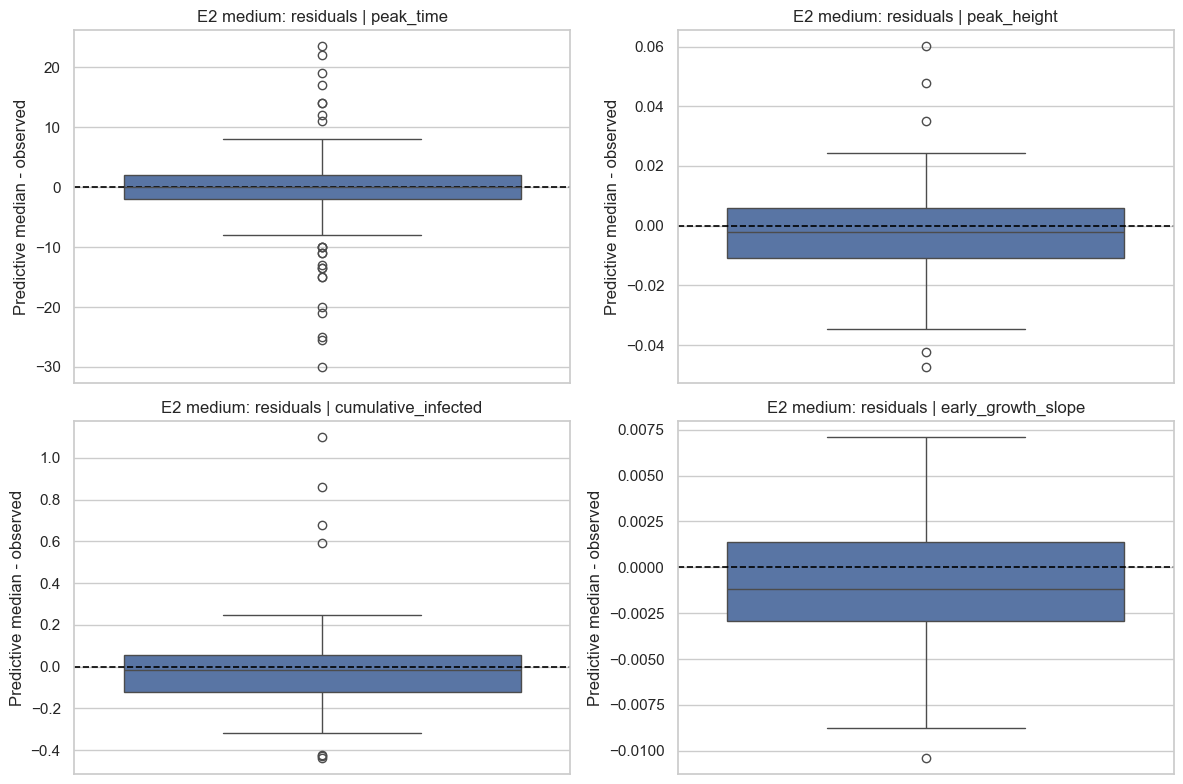

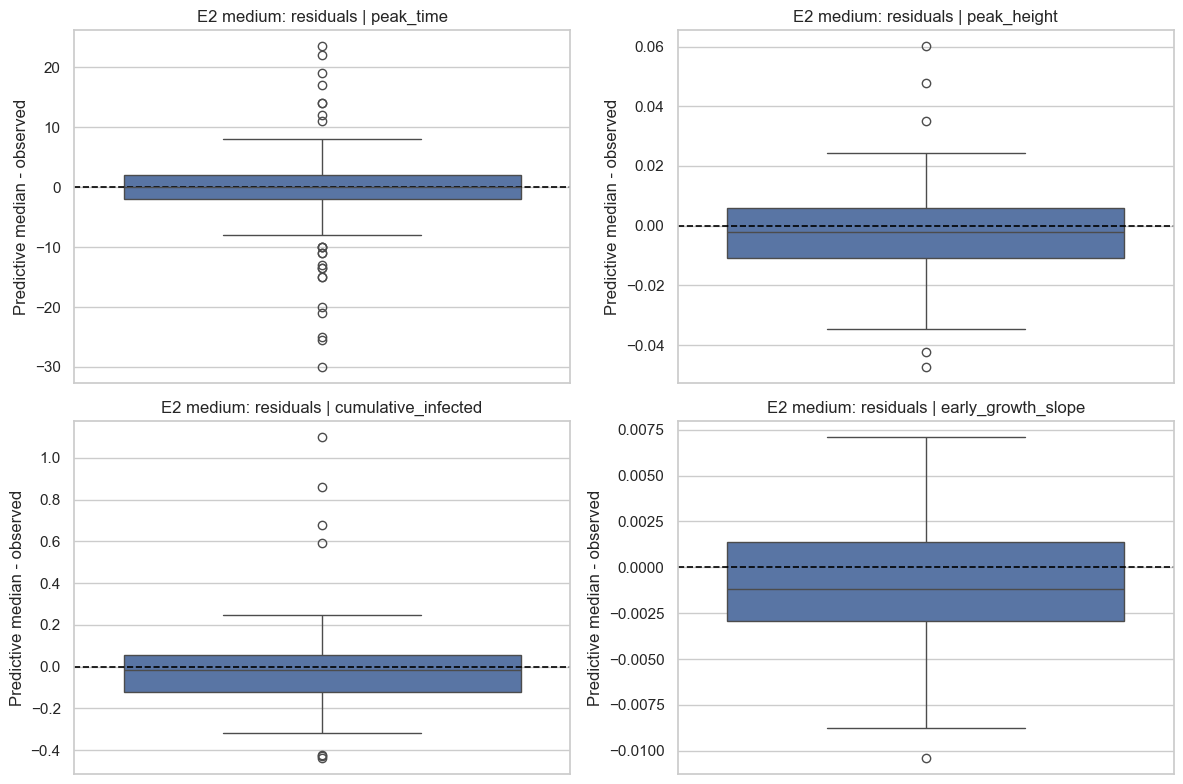

In [12]:
plot_feature_residuals(
    feature_case_df_E2,
    title_prefix="E2 medium",
)


Under medium time-varying transmission misspecification, posterior recovery is still structured, but the degradation in transmission-related quantities becomes much more pronounced than in the mild setting.

The coverage results confirm that posterior calibration degrades sharply at this severity level. For β, empirical coverage drops far below nominal values, while γ remains more stable. This asymmetry suggests that time-varying transmission primarily distorts transmission-related posterior quantities rather than recovery-related ones.


In [13]:
severity_to_run = "strong"
case_df_E2 = severity_outputs[severity_to_run]["case_df"]
strong_recovery_df_E2 = severity_outputs[severity_to_run]["recovery_df"]
strong_coverage_df_E2 = severity_outputs[severity_to_run]["coverage_df"]
feature_case_df_E2 = severity_outputs[severity_to_run]["feature_case_df"]
strong_feature_summary_df_E2 = severity_outputs[severity_to_run]["feature_summary_df"]

display(case_df_E2.head())
display(strong_recovery_df_E2.round(4))
display(strong_coverage_df_E2.round(4))
display(strong_feature_summary_df_E2.round(4))


,case_id,true_beta,true_gamma,true_R0,true_beta_timeavg,true_beta_infweighted,true_R0_timeavg,true_R0_infweighted,beta_ref_mode,beta0,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.065884,0.223647,0.294588,0.065884,0.099914,0.294588,0.446748,time_avg,0.107205,...,0.104364,0.116792,0.116792,0.013640,0.0,0.0,0.466401,0.470273,0.470273,0.221157
1,1,0.438441,0.142269,3.081771,0.438441,0.467879,3.081771,3.288687,time_avg,0.702721,...,0.003435,0.003233,0.003233,0.000010,0.0,0.0,1.652029,1.646977,1.646977,2.712532
2,2,0.268711,0.100655,2.669615,0.268711,0.253533,2.669615,2.518825,time_avg,0.565901,...,0.007547,0.007353,0.007353,0.000054,0.0,0.0,2.492343,2.481692,2.481692,6.158793
3,3,0.087085,0.458047,0.190123,0.087085,0.132836,0.190123,0.290005,time_avg,0.132926,...,-0.123621,-0.106803,0.106803,0.011407,0.0,0.0,0.582102,0.567200,0.567200,0.321716
4,4,0.524505,0.338086,1.551393,0.524505,0.772971,1.551393,2.286311,time_avg,0.797830,...,-0.002673,-0.003530,0.003530,0.000012,0.0,0.0,0.830361,0.826848,0.826848,0.683678


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.2115,0.2093,0.2133,0.2428,0.8908,0.0584
1,gamma,0.0138,0.0198,0.0503,0.0745,0.8389,0.0428
2,R0,0.8272,0.8237,0.8274,1.1237,0.9888,0.2328


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.11,-0.39,0.9,0.23,-0.67,0.0803,0.1870
1,gamma,0.5,0.39,-0.11,0.9,0.73,-0.17,0.0611,0.1372
2,R0,0.5,0.07,-0.43,0.9,0.19,-0.71,0.2886,0.7138


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.65,0.15,0.9,0.92,0.02,0.1485,-0.4850,5.2350,8.7214,6.8210,10.5925,21.0975
1,peak_height,0.5,0.53,0.03,0.9,0.92,0.02,-0.0042,-0.0052,0.0126,0.0169,0.0176,0.0226,0.0550
2,cumulative_infected,0.5,0.77,0.27,0.9,0.99,0.09,-0.0002,-0.0164,0.1082,0.1519,0.2886,0.3469,0.8918
3,early_growth_slope,0.5,0.43,-0.07,0.9,0.92,0.02,-0.0009,-0.0009,0.0026,0.0033,0.0035,0.0046,0.0111


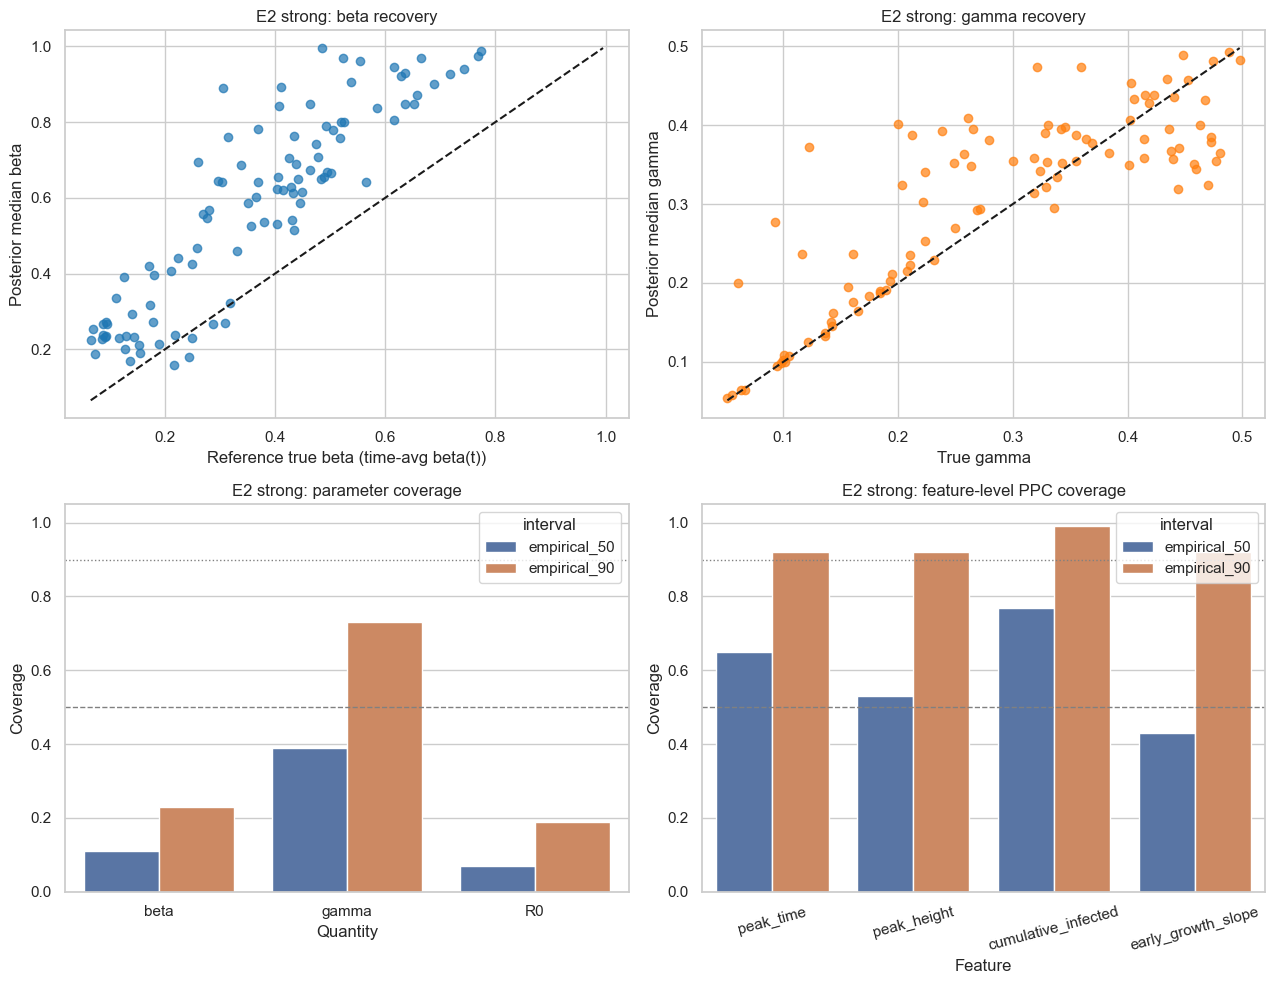

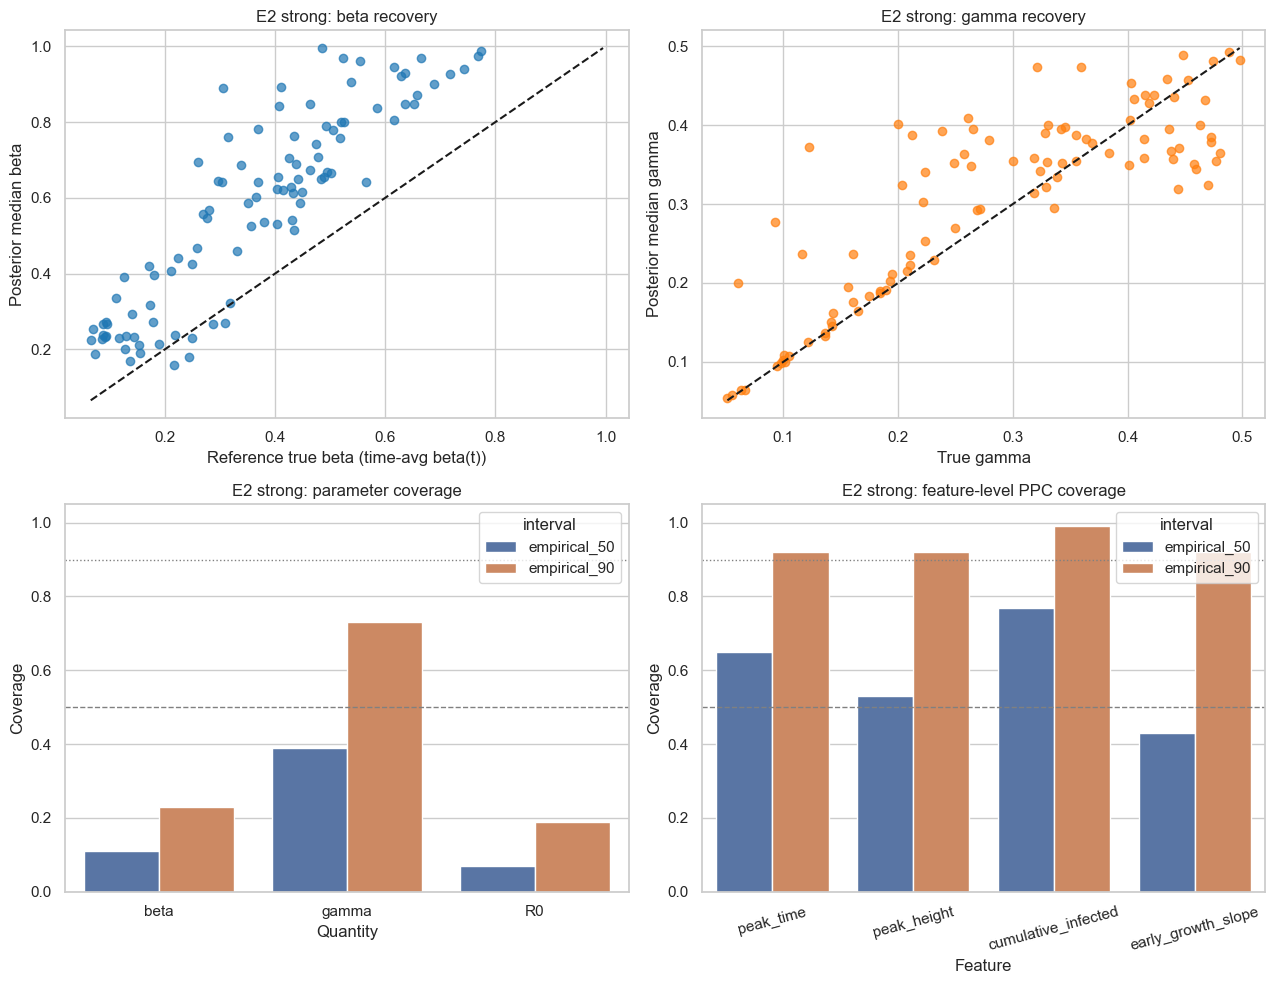

In [14]:
plot_e2_overall_figure(
    case_df_E2,
    strong_coverage_df_E2,
    strong_feature_summary_df_E2,
    severity_label="strong",
    out_path=str(OUTPUTS_ROOT / "E2" / "strong" / "E2_overall_figure.png"),
)


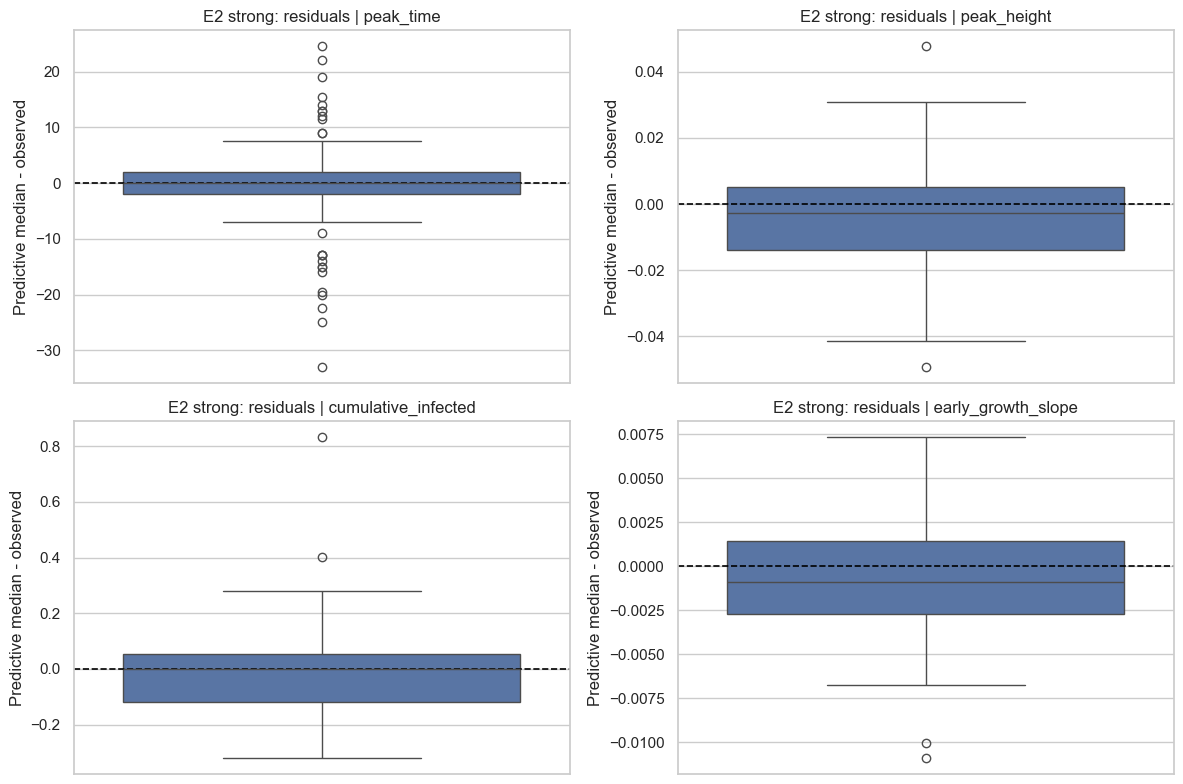

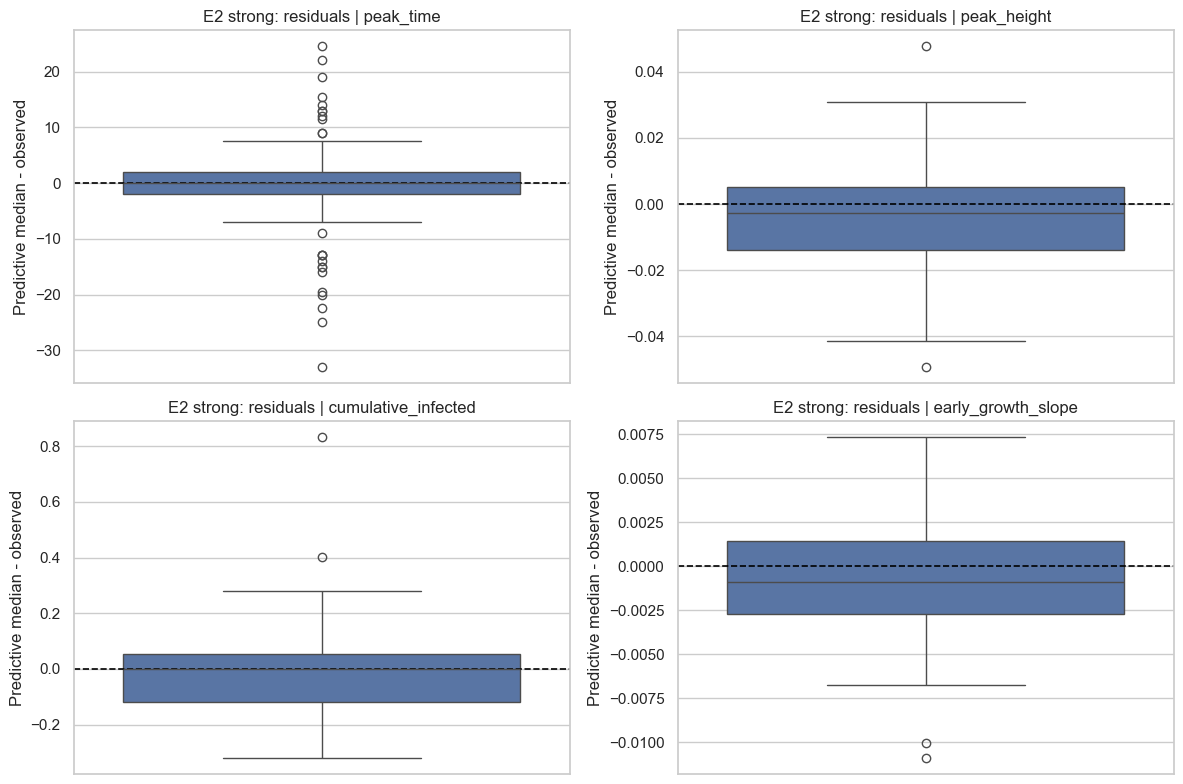

In [15]:
plot_feature_residuals(
    feature_case_df_E2,
    title_prefix="E2 strong",
)


Under strong time-varying transmission misspecification, posterior recovery remains structured but becomes substantially distorted relative to the transmission-related reference quantities. For β, the posterior median exhibits a large positive bias, and the corresponding empirical interval coverage falls dramatically below nominal values.

The coverage results show a corresponding collapse in posterior calibration for β and R0. In contrast, γ still degrades more slowly. This reinforces the interpretation that under E2, transmission misspecification first breaks transmission-related posterior reliability while leaving some recovery-related signal intact.


# E2-main(4 features)

## E2 severity summary + line plots


In [16]:
E2_severity_summary_df = build_E2_severity_summary(
    mild_recovery_df_E2=severity_outputs["mild"]["recovery_df"],
    mild_coverage_df_E2=severity_outputs["mild"]["coverage_df"],
    mild_feature_summary_df_E2=severity_outputs["mild"]["feature_summary_df"],
    medium_recovery_df_E2=severity_outputs["medium"]["recovery_df"],
    medium_coverage_df_E2=severity_outputs["medium"]["coverage_df"],
    medium_feature_summary_df_E2=severity_outputs["medium"]["feature_summary_df"],
    strong_recovery_df_E2=severity_outputs["strong"]["recovery_df"],
    strong_coverage_df_E2=severity_outputs["strong"]["coverage_df"],
    strong_feature_summary_df_E2=severity_outputs["strong"]["feature_summary_df"],
)
E2_severity_summary_unc_df = build_E2_severity_summary_with_uncertainty(severity_outputs)
severity_summary_dir = OUTPUTS_ROOT / "E2" / "severity_summary"
severity_summary_dir.mkdir(parents=True, exist_ok=True)
E2_severity_summary_df.to_csv(severity_summary_dir / "E2_severity_summary.csv", index=False)
E2_severity_summary_unc_df.to_csv(severity_summary_dir / "E2_severity_summary_with_uncertainty.csv", index=False)
display(E2_severity_summary_unc_df.round(4))


,severity,beta_bias_median,beta_bias_ci_low,beta_bias_ci_high,beta_MAE,beta_empirical_90,beta_empirical_90_ci_low,beta_empirical_90_ci_high,gamma_empirical_90,R0_empirical_90,R0_empirical_90_ci_low,R0_empirical_90_ci_high,peak_time_MAE,early_growth_slope_empirical_50
0,mild,0.0283,0.0172,0.0451,0.0548,0.78,0.6893,0.8500,0.96,0.82,0.7333,0.8830,5.195,0.45
1,medium,0.1044,0.0930,0.1214,0.1177,0.31,0.2278,0.4063,0.78,0.36,0.2727,0.4576,5.365,0.39
2,strong,0.2072,0.1783,0.2179,0.2133,0.23,0.1584,0.3215,0.73,0.19,0.1251,0.2778,5.235,0.43


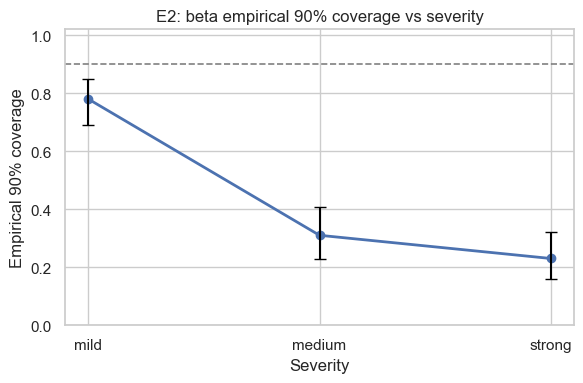

In [17]:
plot_E2_severity_single_line(
    E2_severity_summary_unc_df,
    metric="beta_empirical_90",
    out_path=str(OUTPUTS_ROOT / "E2" / "severity_summary" / "E2_beta_empirical90_vs_severity.png"),
)


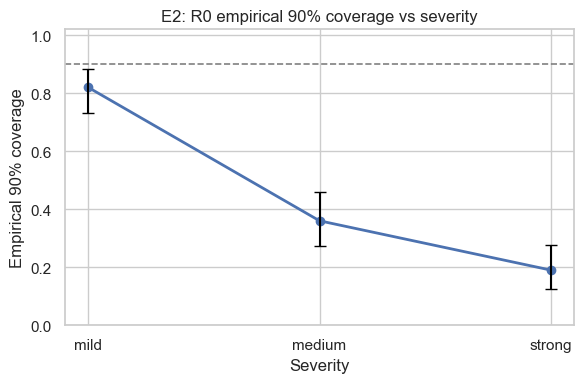

In [18]:
plot_E2_severity_single_line(
    E2_severity_summary_unc_df,
    metric="R0_empirical_90",
    out_path=str(OUTPUTS_ROOT / "E2" / "severity_summary" / "E2_R0_empirical90_vs_severity.png"),
)


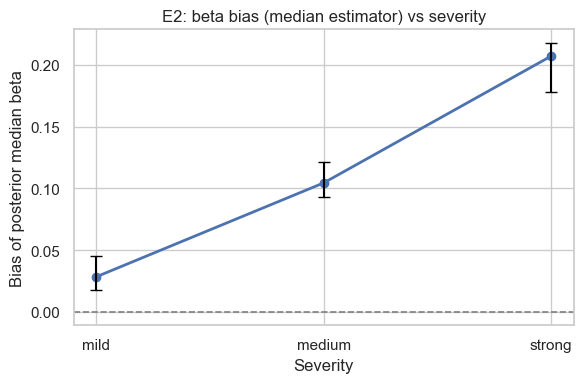

In [19]:
plot_E2_severity_single_line(
    E2_severity_summary_unc_df,
    metric="beta_bias_median",
    out_path=str(OUTPUTS_ROOT / "E2" / "severity_summary" / "E2_beta_bias_median_vs_severity.png"),
)


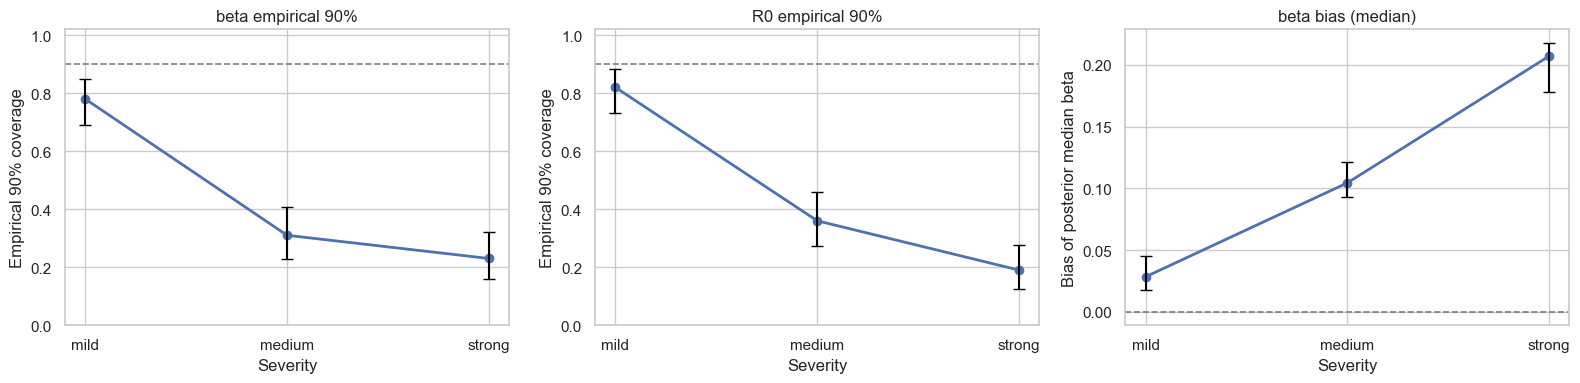

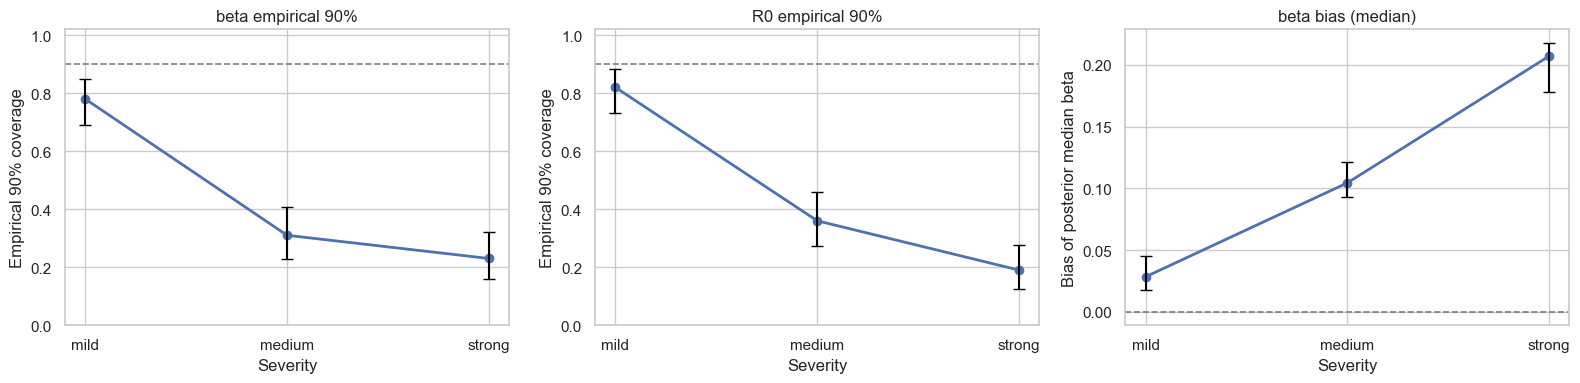

In [20]:
plot_E2_severity_3panel_summary(
    E2_severity_summary_unc_df,
    out_path=str(OUTPUTS_ROOT / "E2" / "severity_summary" / "E2_severity_3panel_summary.png"),
)


Under E2, posterior degradation increases systematically with misspecification severity. The median bias of beta rises monotonically from mild to strong misspecification, while empirical 90% coverage for beta and R0 drops sharply. This supports a clear severity-dependent interpretation: time-varying transmission misspecification first breaks transmission-related posterior reliability, and it does so in a way that becomes progressively worse as the post-change transmission reduction becomes stronger.
1. 时变 transmission misspecification 主要先破坏 transmission-related quantities（beta 和 R0）的 posterior reliability，而 gamma 相对更稳。
2. 当前的这两个 PPC 指标对 severity 不敏感。


In [21]:
# reference sensitivity under different beta references

E2_reference_sensitivity_df = build_E2_reference_sensitivity_summary(
    workflow=workflow_E0,
    n_test=100,
    num_posterior_samples=2000,
    n_ppc_draws=100,
    seed=2027,
)
ref_dir = OUTPUTS_ROOT / "E2" / "reference_sensitivity"
ref_dir.mkdir(parents=True, exist_ok=True)
E2_reference_sensitivity_df.to_csv(ref_dir / "E2_reference_sensitivity_summary.csv", index=False)
display(E2_reference_sensitivity_df.round(4))


,severity,beta_ref_mode,beta_bias_median,beta_empirical_90,R0_empirical_90
0,mild,infection_weighted,0.0170,0.84,0.86
1,medium,infection_weighted,0.0559,0.61,0.70
2,strong,infection_weighted,0.1040,0.48,0.56
3,mild,time_avg,0.0296,0.77,0.81
4,medium,time_avg,0.1045,0.33,0.36
5,strong,time_avg,0.2092,0.23,0.19


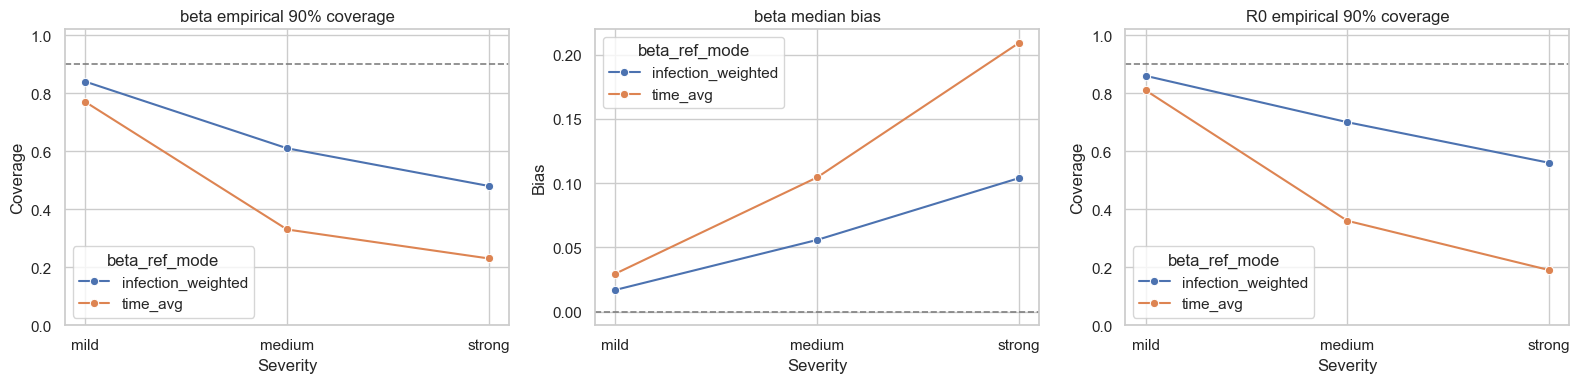

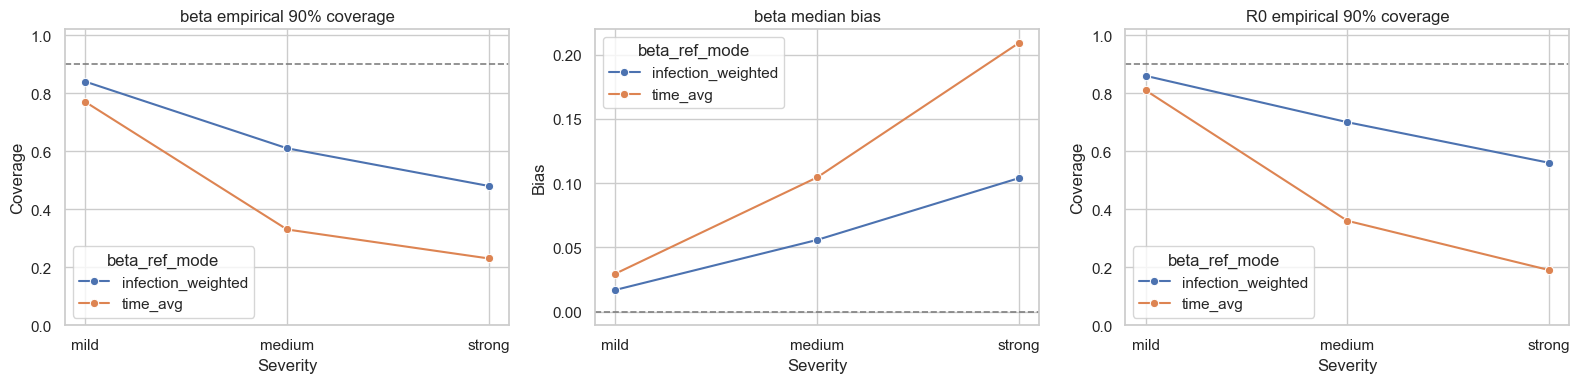

In [22]:
plot_E2_reference_sensitivity(
    E2_reference_sensitivity_df,
    out_dir=str(OUTPUTS_ROOT / "E2" / "reference_sensitivity"),
)


In [23]:
extended_feature_names = [
    "peak_time",
    "peak_height",
    "cumulative_infected",
    "early_growth_slope",
    "post_peak_decline_slope",
    "late_phase_auc",
    "time_to_half_peak_after_peak",
    "late_to_early_mean_ratio",
]

extended_feature_outputs = {}
for sev in ["mild", "medium", "strong"]:
    feature_case_df_E2_ext, feature_summary_df_E2_ext = run_extended_E2_feature_evaluation(
        workflow=workflow_E0,
        severity=sev,
        n_test=100,
        num_posterior_samples=1000,
        n_ppc_draws=100,
        seed=2026,
    )
    extended_feature_outputs[sev] = {
        "feature_case_df": feature_case_df_E2_ext,
        "feature_summary_df": feature_summary_df_E2_ext,
    }
    out_dir = OUTPUTS_ROOT / "E2" / sev
    feature_case_df_E2_ext.to_csv(out_dir / "E2_ppc_feature_case_level_extended.csv", index=False)
    feature_summary_df_E2_ext.to_csv(out_dir / "E2_ppc_feature_summary_extended.csv", index=False)


The extended feature-level PPC analysis was designed to test whether more dynamics-aware summaries would reveal a clearer misspecification signal than the original four coarse features. Across the three severity settings, the extended features do reveal additional asymmetries, but they still do not collapse as sharply as the posterior coverage diagnostics for β and R0. This is important: even more refined predictive summaries may fail to fully expose posterior unreliability under structural or dynamical misspecification.


In [24]:
display(extended_feature_outputs["mild"]["feature_summary_df"].round(4))


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.66,0.16,0.9,0.96,0.06,0.0966,-0.3500,4.3500,7.4391,5.3712,8.5075,16.4945
1,peak_height,0.5,0.59,0.09,0.9,0.96,0.06,-0.0024,-0.0033,0.0116,0.0151,0.0200,0.0257,0.0641
2,cumulative_infected,0.5,0.78,0.28,0.9,0.98,0.08,-0.0232,-0.0415,0.1241,0.1675,0.3643,0.4482,1.1553
3,early_growth_slope,0.5,0.46,-0.04,0.9,0.91,0.01,-0.0010,-0.0009,0.0025,0.0030,0.0033,0.0043,0.0106
4,post_peak_decline_slope,0.5,0.62,0.12,0.9,0.92,0.02,0.0002,0.0004,0.0023,0.0030,0.0042,0.0042,0.0112
5,late_phase_auc,0.5,0.69,0.19,0.9,0.96,0.06,0.0130,0.0028,0.0872,0.1298,0.2139,0.2538,0.6673
6,time_to_half_peak_after_peak,0.5,0.70,0.20,0.9,0.96,0.06,0.0982,-0.0950,1.1850,2.0597,1.7859,2.2175,5.3120
7,late_to_early_mean_ratio,0.5,0.63,0.13,0.9,0.93,0.03,0.0130,-0.0103,0.1121,0.2044,0.1883,0.2213,0.5791


In [25]:
display(extended_feature_outputs["medium"]["feature_summary_df"].round(4))


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.66,0.16,0.9,0.99,0.09,0.2071,-0.3050,4.3050,7.2541,5.4659,8.4725,16.7510
1,peak_height,0.5,0.53,0.03,0.9,0.95,0.05,-0.0004,-0.0011,0.0145,0.0202,0.0196,0.0253,0.0625
2,cumulative_infected,0.5,0.76,0.26,0.9,0.99,0.09,0.0252,0.0154,0.1385,0.2045,0.3433,0.4343,1.0714
3,early_growth_slope,0.5,0.47,-0.03,0.9,0.90,0.00,-0.0010,-0.0010,0.0025,0.0030,0.0033,0.0044,0.0106
4,post_peak_decline_slope,0.5,0.54,0.04,0.9,0.91,0.01,0.0003,0.0005,0.0023,0.0030,0.0040,0.0041,0.0108
5,late_phase_auc,0.5,0.68,0.18,0.9,0.94,0.04,0.0544,0.0508,0.1005,0.1752,0.1968,0.2425,0.5995
6,time_to_half_peak_after_peak,0.5,0.72,0.22,0.9,0.95,0.05,0.2552,0.0650,1.1350,1.8145,1.6992,2.1650,5.1740
7,late_to_early_mean_ratio,0.5,0.64,0.14,0.9,0.92,0.02,0.0454,0.0212,0.1100,0.1994,0.1841,0.2150,0.5606


In [26]:
display(extended_feature_outputs["strong"]["feature_summary_df"].round(4))


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.66,0.16,0.9,0.93,0.03,0.5070,-0.0500,4.4100,7.3291,5.6872,8.7425,17.1865
1,peak_height,0.5,0.51,0.01,0.9,0.92,0.02,-0.0023,-0.0030,0.0152,0.0223,0.0186,0.0237,0.0588
2,cumulative_infected,0.5,0.71,0.21,0.9,0.99,0.09,0.0390,0.0252,0.1377,0.2118,0.3148,0.3879,0.9753
3,early_growth_slope,0.5,0.46,-0.04,0.9,0.89,-0.01,-0.0010,-0.0009,0.0025,0.0031,0.0034,0.0044,0.0108
4,post_peak_decline_slope,0.5,0.55,0.05,0.9,0.91,0.01,0.0005,0.0007,0.0025,0.0034,0.0039,0.0040,0.0105
5,late_phase_auc,0.5,0.61,0.11,0.9,0.91,0.01,0.0640,0.0542,0.0971,0.1613,0.1721,0.1988,0.5133
6,time_to_half_peak_after_peak,0.5,0.70,0.20,0.9,0.94,0.04,0.0578,-0.1800,1.2900,2.0579,1.6538,2.0725,4.9165
7,late_to_early_mean_ratio,0.5,0.50,0.00,0.9,0.92,0.02,0.0652,0.0396,0.1168,0.1971,0.1779,0.2127,0.5286


# curve-level PPC for all severities

## 在整条感染曲线层面，constant-β posterior predictive 到底在哪些时间段开始跟不上 time-varying β(t) 的观测？而且这种 discrepancy 会不会随 severity 变强？


In [27]:
curve_outputs = {}
for sev in ["mild", "medium", "strong"]:
    curve_case_df_E2, curve_summary_df_E2 = evaluate_curve_level_ppc(
        workflow=workflow_E0,
        case_simulator=lambda rng=None, severity=sev: simulate_case_E2(rng=rng, severity=severity),
        predictive_curve_simulator=simulate_curve,
        n_test=100,
        num_posterior_samples=1000,
        n_ppc_draws=100,
        seed=2026,
        split_mode="fraction",
        split_frac=0.5,
    )
    curve_outputs[sev] = {
        "case_df": curve_case_df_E2,
        "summary_df": curve_summary_df_E2,
    }
    out_dir = OUTPUTS_ROOT / "E2" / "curve_level" / sev
    out_dir.mkdir(parents=True, exist_ok=True)
    curve_case_df_E2.to_csv(out_dir / f"E2_curve_case_level_{sev}.csv", index=False)
    curve_summary_df_E2.to_csv(out_dir / f"E2_curve_summary_{sev}.csv", index=False)


In [28]:
display(curve_outputs["mild"]["summary_df"].round(4))
display(curve_outputs["mild"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6362,0.1019,0.6200,0.4800,0.8210
1,pointwise_empirical_90,0.9344,0.0374,0.9400,0.8790,0.9800
2,curve_bias_full,-0.0033,0.0035,-0.0036,-0.0078,0.0027
3,curve_mae_full,0.0141,0.0033,0.0140,0.0082,0.0197
4,curve_rmse_full,0.0185,0.0034,0.0185,0.0125,0.0245
5,curve_bias_first,-0.0035,0.0042,-0.0036,-0.0101,0.0036
6,curve_mae_first,0.0153,0.0034,0.0156,0.0087,0.0205
7,curve_rmse_first,0.0194,0.0036,0.0198,0.0120,0.0253
8,curve_bias_second,-0.0032,0.0060,-0.0040,-0.0114,0.0086
9,curve_mae_second,0.0129,0.0044,0.0119,0.0068,0.0213


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,true_beta_timeavg,true_beta_infweighted,true_R0_timeavg,true_R0_infweighted,beta_ref_mode,beta0,gamma,tau,kappa,severity
0,0,0.72,0.92,-0.0070,0.0115,0.0163,-0.0020,0.0087,0.0109,-0.0119,...,0.2448,0.2563,0.7243,0.7584,time_avg,0.2610,0.3380,17,0.9056,mild
1,1,0.54,0.92,0.0023,0.0180,0.0226,-0.0019,0.0166,0.0209,0.0064,...,0.3560,0.3506,3.7975,3.7399,time_avg,0.3843,0.0938,16,0.8919,mild
2,2,0.84,0.98,-0.0032,0.0078,0.0121,-0.0027,0.0087,0.0144,-0.0036,...,0.2680,0.2746,0.6325,0.6480,time_avg,0.2754,0.4238,17,0.9597,mild
3,3,0.60,0.90,-0.0037,0.0140,0.0187,-0.0073,0.0170,0.0220,-0.0002,...,0.4925,0.4975,2.3604,2.3841,time_avg,0.5088,0.2087,20,0.9466,mild
4,4,0.76,0.98,-0.0063,0.0114,0.0150,-0.0065,0.0124,0.0170,-0.0061,...,0.1665,0.1706,0.8902,0.9122,time_avg,0.1825,0.1870,20,0.8532,mild


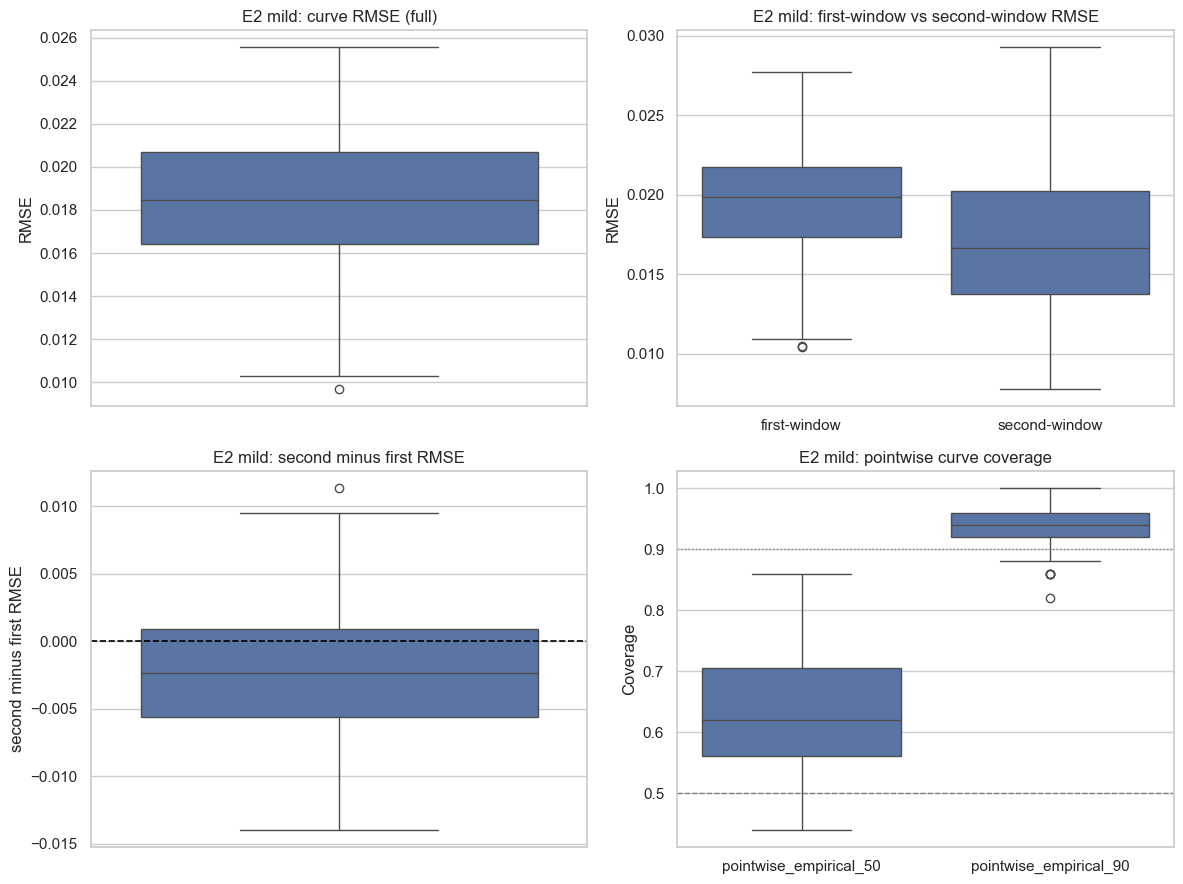

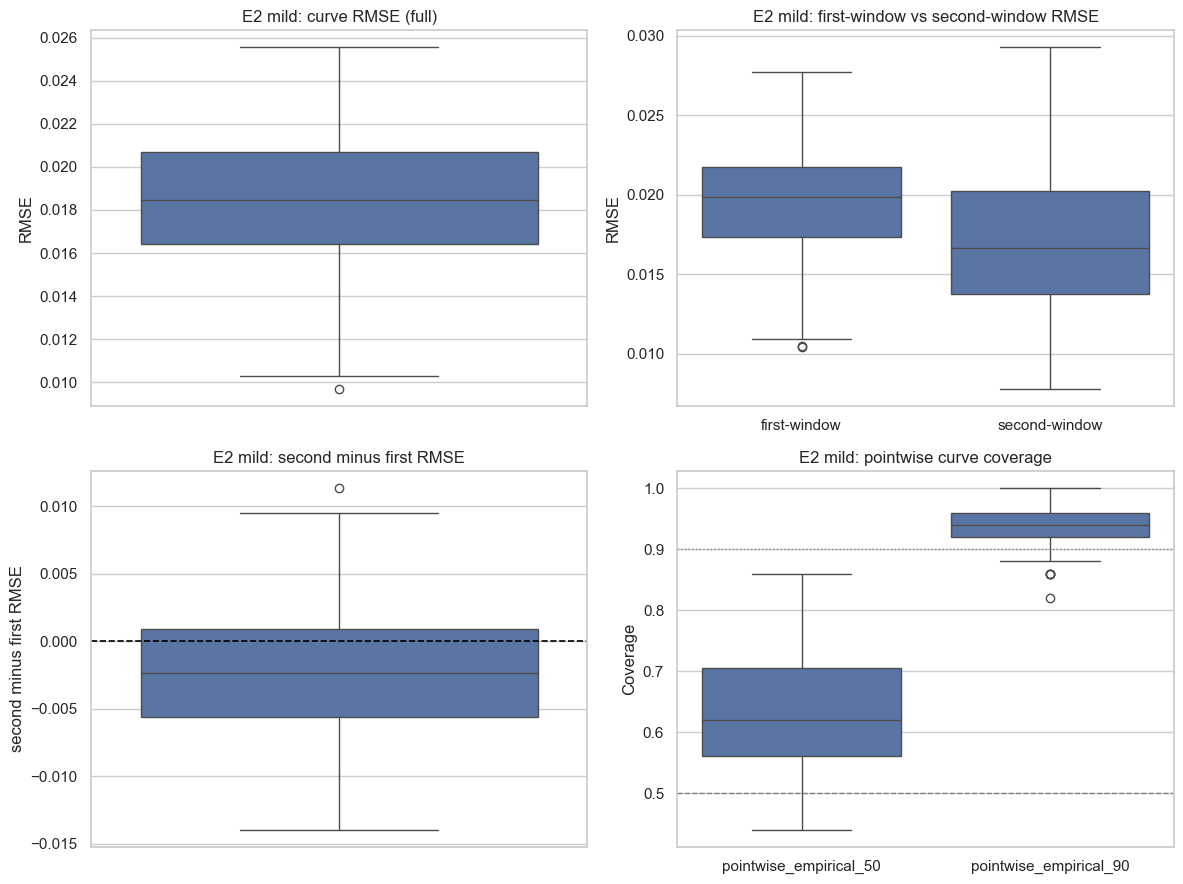

In [29]:
plot_curve_level_ppc_summary(
    curve_outputs["mild"]["case_df"],
    severity_label="mild",
    experiment_label="E2",
    out_dir=str(OUTPUTS_ROOT / "E2" / "curve_level" / "mild"),
    split_mode="fraction",
)


In [30]:
display(curve_outputs["medium"]["summary_df"].round(4))
display(curve_outputs["medium"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6326,0.1079,0.6200,0.4600,0.8020
1,pointwise_empirical_90,0.9274,0.0455,0.9400,0.8600,0.9800
2,curve_bias_full,-0.0023,0.0047,-0.0036,-0.0072,0.0086
3,curve_mae_full,0.0144,0.0043,0.0140,0.0079,0.0228
4,curve_rmse_full,0.0191,0.0048,0.0186,0.0124,0.0278
5,curve_bias_first,-0.0031,0.0048,-0.0030,-0.0099,0.0046
6,curve_mae_first,0.0159,0.0043,0.0158,0.0087,0.0223
7,curve_rmse_first,0.0201,0.0049,0.0199,0.0119,0.0277
8,curve_bias_second,-0.0015,0.0077,-0.0033,-0.0097,0.0123
9,curve_mae_second,0.0130,0.0056,0.0113,0.0065,0.0239


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,true_beta_timeavg,true_beta_infweighted,true_R0_timeavg,true_R0_infweighted,beta_ref_mode,beta0,gamma,tau,kappa,severity
0,0,0.72,0.92,-0.0072,0.0117,0.0166,-0.0023,0.0093,0.0118,-0.0120,...,0.2081,0.2495,0.6157,0.7383,time_avg,0.2610,0.3380,17,0.6926,medium
1,1,0.42,0.84,0.0056,0.0231,0.0284,0.0031,0.0223,0.0277,0.0081,...,0.2980,0.2827,3.1786,3.0153,time_avg,0.3843,0.0938,16,0.6699,medium
2,2,0.84,0.98,-0.0031,0.0077,0.0121,-0.0027,0.0087,0.0143,-0.0035,...,0.2359,0.2721,0.5566,0.6421,time_avg,0.2754,0.4238,17,0.7828,medium
3,3,0.58,0.88,-0.0038,0.0148,0.0198,-0.0087,0.0182,0.0236,0.0011,...,0.4358,0.4603,2.0888,2.2062,time_avg,0.5088,0.2087,20,0.7609,medium
4,4,0.76,0.98,-0.0062,0.0107,0.0145,-0.0074,0.0121,0.0171,-0.0050,...,0.1393,0.1578,0.7450,0.8441,time_avg,0.1825,0.1870,20,0.6053,medium


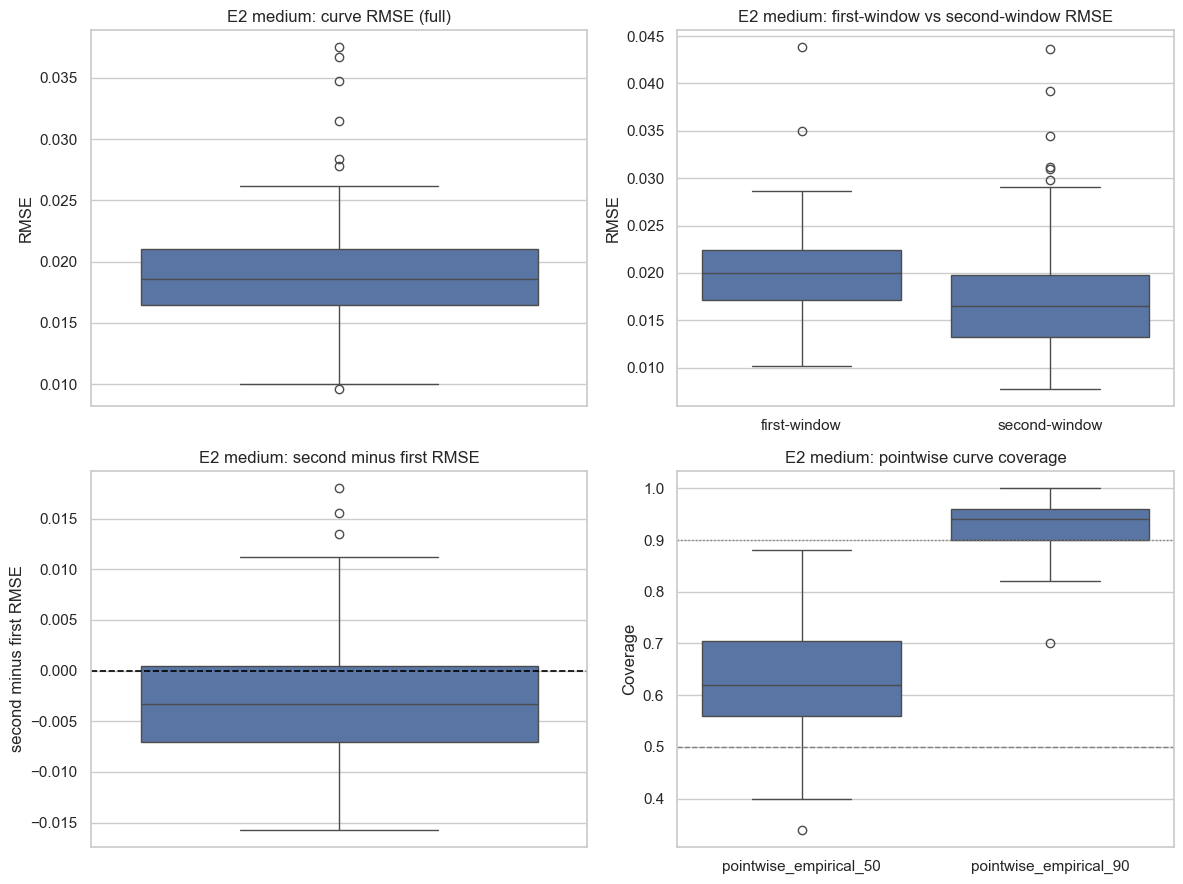

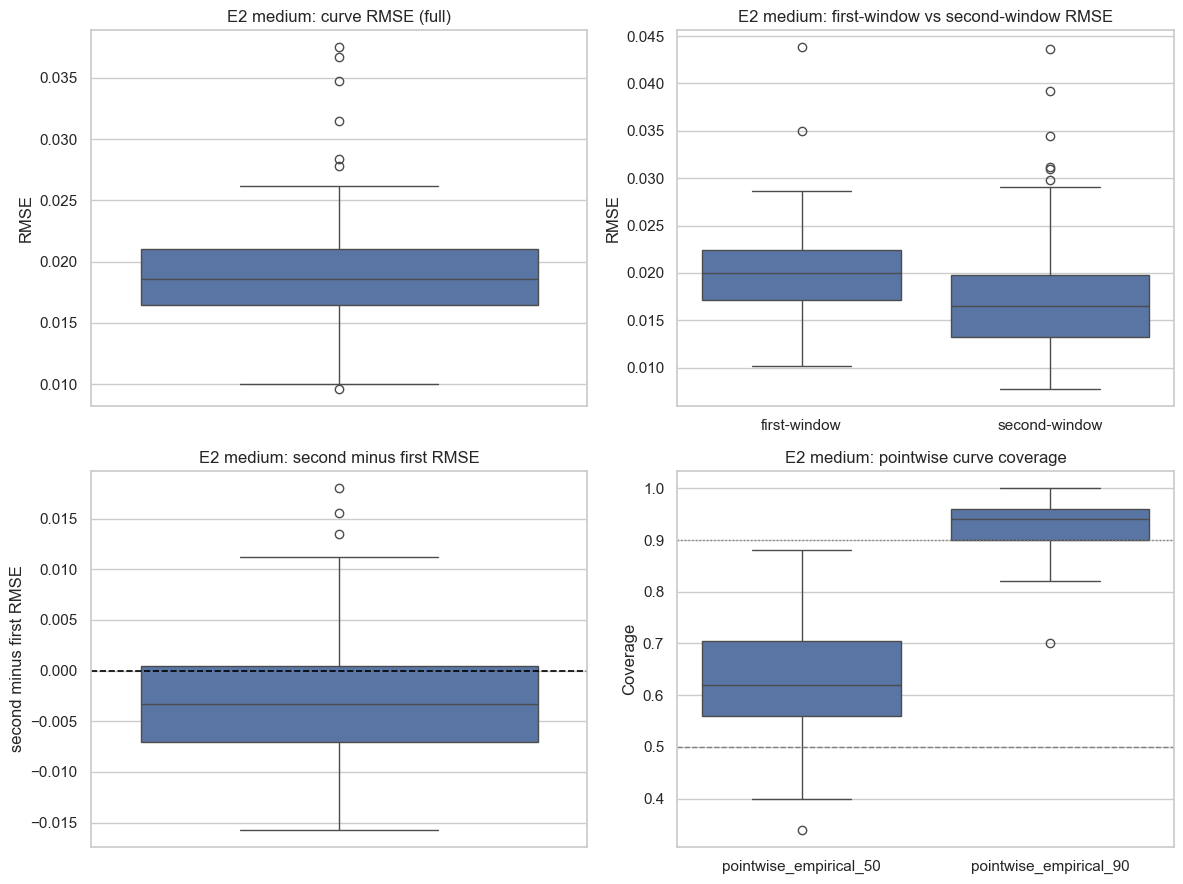

In [31]:
plot_curve_level_ppc_summary(
    curve_outputs["medium"]["case_df"],
    severity_label="medium",
    experiment_label="E2",
    out_dir=str(OUTPUTS_ROOT / "E2" / "curve_level" / "medium"),
    split_mode="fraction",
)


In [32]:
display(curve_outputs["strong"]["summary_df"].round(4))
display(curve_outputs["strong"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6248,0.1256,0.6200,0.4390,0.8200
1,pointwise_empirical_90,0.9140,0.0724,0.9400,0.8140,0.9800
2,curve_bias_full,-0.0022,0.0048,-0.0036,-0.0070,0.0070
3,curve_mae_full,0.0148,0.0059,0.0138,0.0081,0.0270
4,curve_rmse_full,0.0197,0.0070,0.0182,0.0124,0.0338
5,curve_bias_first,-0.0031,0.0055,-0.0036,-0.0105,0.0065
6,curve_mae_first,0.0165,0.0055,0.0159,0.0089,0.0249
7,curve_rmse_first,0.0211,0.0068,0.0202,0.0118,0.0292
8,curve_bias_second,-0.0013,0.0074,-0.0030,-0.0092,0.0140
9,curve_mae_second,0.0132,0.0076,0.0111,0.0065,0.0257


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,true_beta_timeavg,true_beta_infweighted,true_R0_timeavg,true_R0_infweighted,beta_ref_mode,beta0,gamma,tau,kappa,severity
0,0,0.76,0.92,-0.0068,0.0113,0.0160,-0.0022,0.0090,0.0113,-0.0114,...,0.1596,0.2444,0.4722,0.7231,time_avg,0.2610,0.3380,17,0.4112,strong
1,1,0.30,0.70,0.0069,0.0291,0.0366,0.0064,0.0291,0.0373,0.0074,...,0.2233,0.2016,2.3814,2.1499,time_avg,0.3843,0.0938,16,0.3839,strong
2,2,0.84,0.98,-0.0029,0.0081,0.0122,-0.0022,0.0094,0.0146,-0.0035,...,0.1880,0.2697,0.4436,0.6363,time_avg,0.2754,0.4238,17,0.5194,strong
3,3,0.56,0.86,-0.0041,0.0162,0.0219,-0.0108,0.0209,0.0268,0.0026,...,0.3541,0.4144,1.6969,1.9862,time_avg,0.5088,0.2087,20,0.4931,strong
4,4,0.78,0.98,-0.0059,0.0103,0.0141,-0.0070,0.0121,0.0168,-0.0049,...,0.1066,0.1496,0.5699,0.7999,time_avg,0.1825,0.1870,20,0.3064,strong


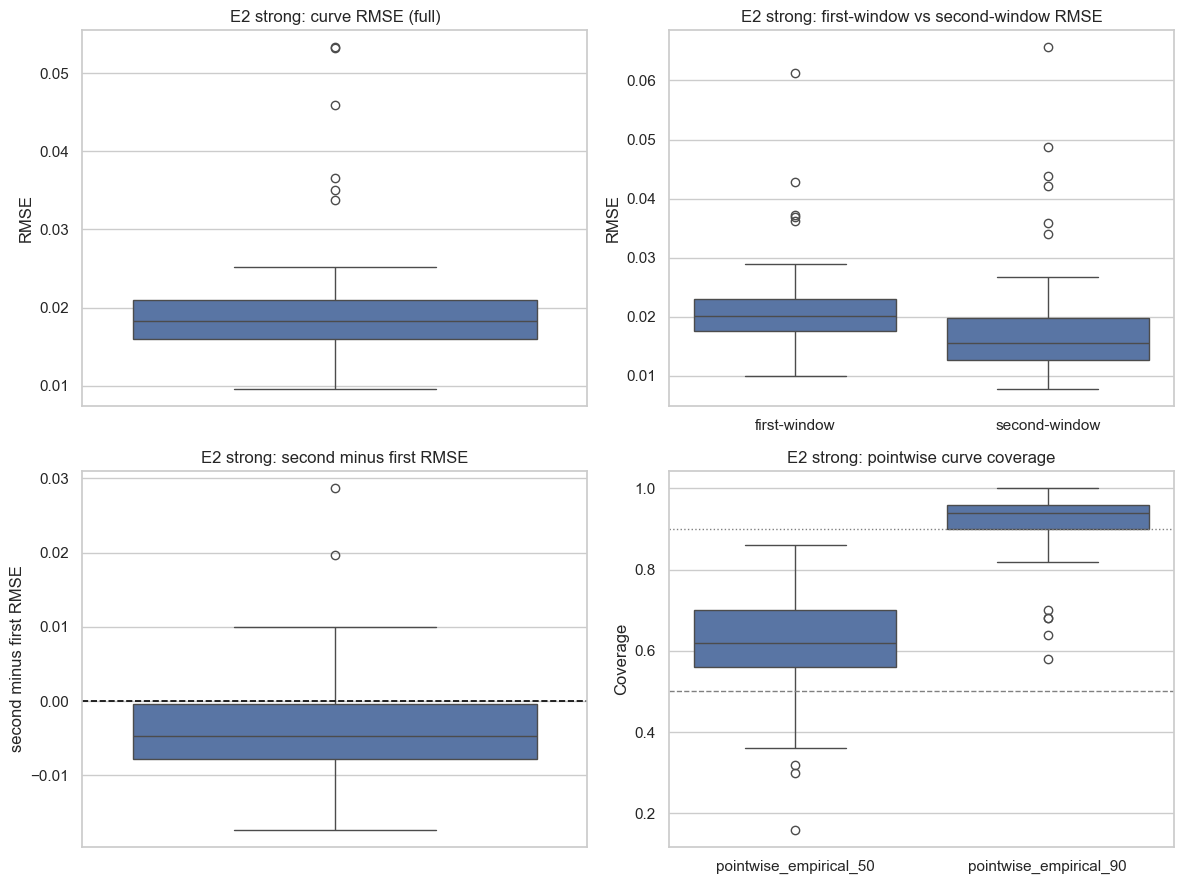

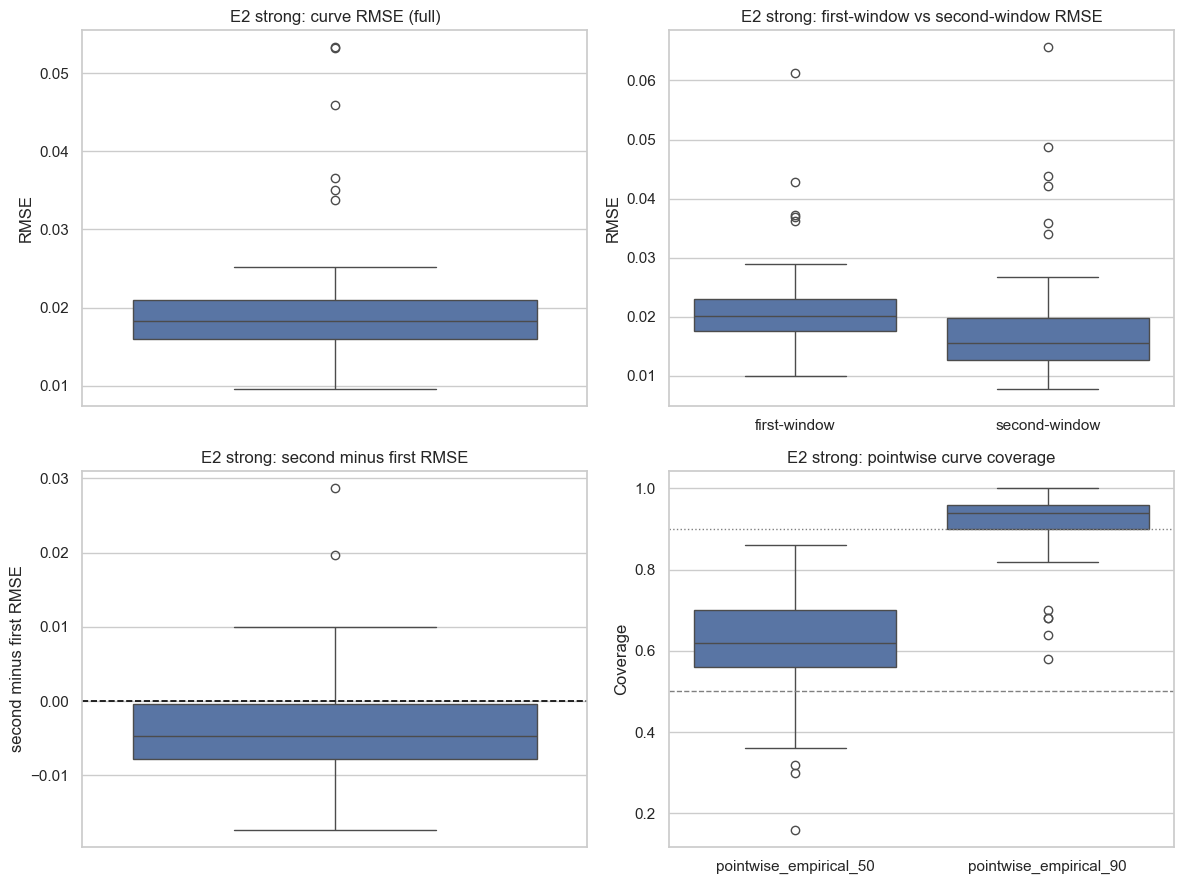

In [33]:
plot_curve_level_ppc_summary(
    curve_outputs["strong"]["case_df"],
    severity_label="strong",
    experiment_label="E2",
    out_dir=str(OUTPUTS_ROOT / "E2" / "curve_level" / "strong"),
    split_mode="fraction",
)


The curve-level PPC results show that, across the mild, medium, and strong misspecification settings, posterior predictive curves remain comparatively close to the observed trajectories, even when parameter posterior reliability is already degrading substantially. This again highlights the key cautionary point of E2: low-dimensional or even full-curve predictive adequacy does not guarantee that posterior parameter uncertainty is still trustworthy.


# E2 tau-aligned curve-level PPC
# pre-change = t < tau
# post-change = t >= tau

# E2 tau-aligned curve-level PPC
pre-change = t < tau
post-change = t >= tau


In [34]:
curve_tau_outputs = {}
for sev in ["mild", "medium", "strong"]:
    curve_case_df_E2_tau, curve_summary_df_E2_tau = evaluate_curve_level_ppc(
        workflow=workflow_E0,
        case_simulator=lambda rng=None, severity=sev: simulate_case_E2(rng=rng, severity=severity),
        predictive_curve_simulator=simulate_curve,
        n_test=100,
        num_posterior_samples=1000,
        n_ppc_draws=100,
        seed=2026,
        split_mode="tau",
        split_frac=0.5,
    )
    curve_tau_outputs[sev] = {
        "case_df": curve_case_df_E2_tau,
        "summary_df": curve_summary_df_E2_tau,
    }
    out_dir = OUTPUTS_ROOT / "E2" / "curve_level_tau" / sev
    out_dir.mkdir(parents=True, exist_ok=True)
    curve_case_df_E2_tau.to_csv(out_dir / f"E2_curve_case_level_tau_{sev}.csv", index=False)
    curve_summary_df_E2_tau.to_csv(out_dir / f"E2_curve_summary_tau_{sev}.csv", index=False)


In [35]:
display(curve_tau_outputs["mild"]["summary_df"].round(4))
display(curve_tau_outputs["mild"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6320,0.1033,0.6200,0.4800,0.8210
1,pointwise_empirical_90,0.9356,0.0359,0.9400,0.8790,0.9810
2,curve_bias_full,-0.0034,0.0035,-0.0037,-0.0077,0.0041
3,curve_mae_full,0.0141,0.0032,0.0139,0.0083,0.0195
4,curve_rmse_full,0.0185,0.0033,0.0186,0.0124,0.0244
5,curve_bias_first,-0.0040,0.0049,-0.0036,-0.0122,0.0030
6,curve_mae_first,0.0154,0.0037,0.0157,0.0089,0.0204
7,curve_rmse_first,0.0193,0.0041,0.0194,0.0123,0.0253
8,curve_bias_second,-0.0031,0.0052,-0.0037,-0.0103,0.0068
9,curve_mae_second,0.0131,0.0040,0.0127,0.0077,0.0212


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,true_beta_timeavg,true_beta_infweighted,true_R0_timeavg,true_R0_infweighted,beta_ref_mode,beta0,gamma,tau,kappa,severity
0,0,0.70,0.92,-0.0070,0.0113,0.0163,-0.0002,0.0063,0.0073,-0.0106,...,0.2448,0.2563,0.7243,0.7584,time_avg,0.2610,0.3380,17,0.9056,mild
1,1,0.48,0.94,-0.0005,0.0183,0.0230,-0.0077,0.0188,0.0224,0.0029,...,0.3560,0.3506,3.7975,3.7399,time_avg,0.3843,0.0938,16,0.8919,mild
2,2,0.84,0.98,-0.0028,0.0081,0.0122,-0.0031,0.0104,0.0164,-0.0026,...,0.2680,0.2746,0.6325,0.6480,time_avg,0.2754,0.4238,17,0.9597,mild
3,3,0.60,0.92,-0.0036,0.0138,0.0187,-0.0052,0.0144,0.0200,-0.0026,...,0.4925,0.4975,2.3604,2.3841,time_avg,0.5088,0.2087,20,0.9466,mild
4,4,0.70,0.98,-0.0077,0.0117,0.0156,-0.0083,0.0137,0.0188,-0.0074,...,0.1665,0.1706,0.8902,0.9122,time_avg,0.1825,0.1870,20,0.8532,mild


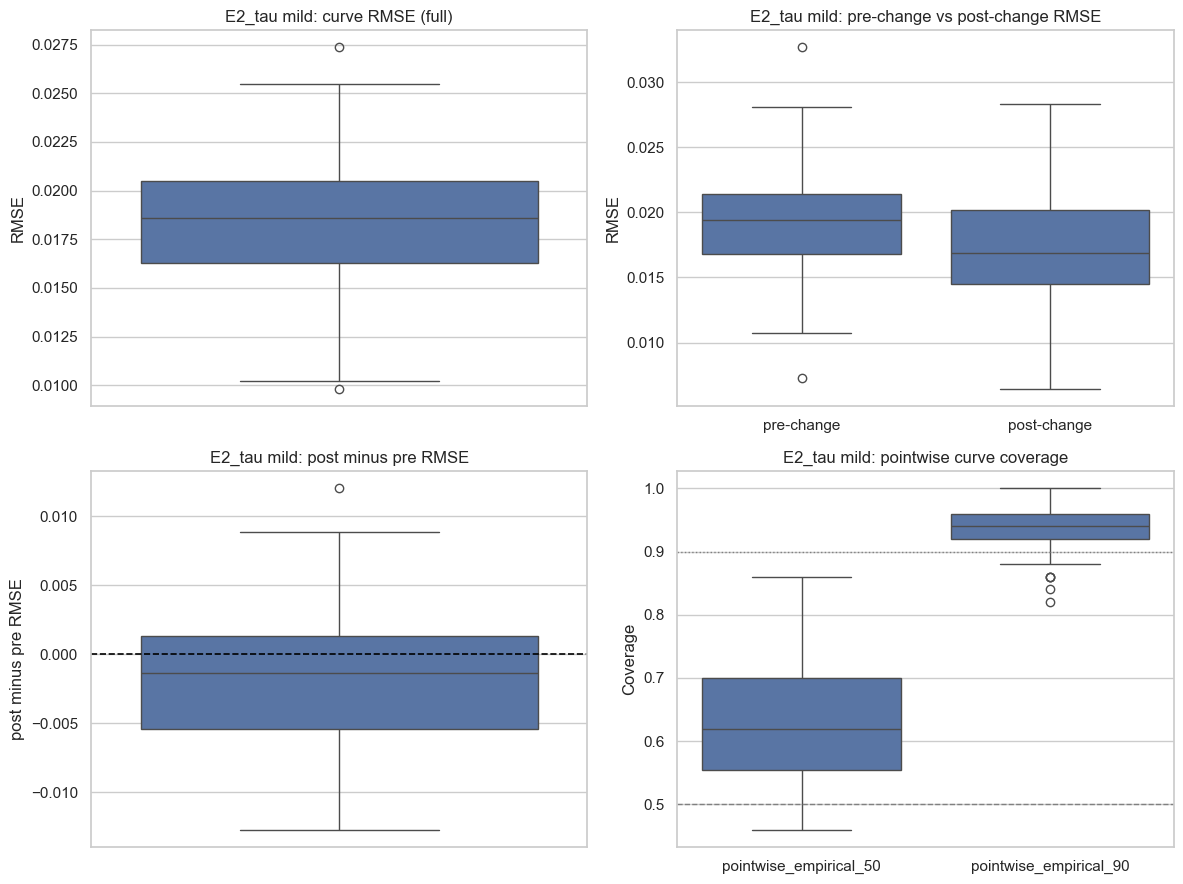

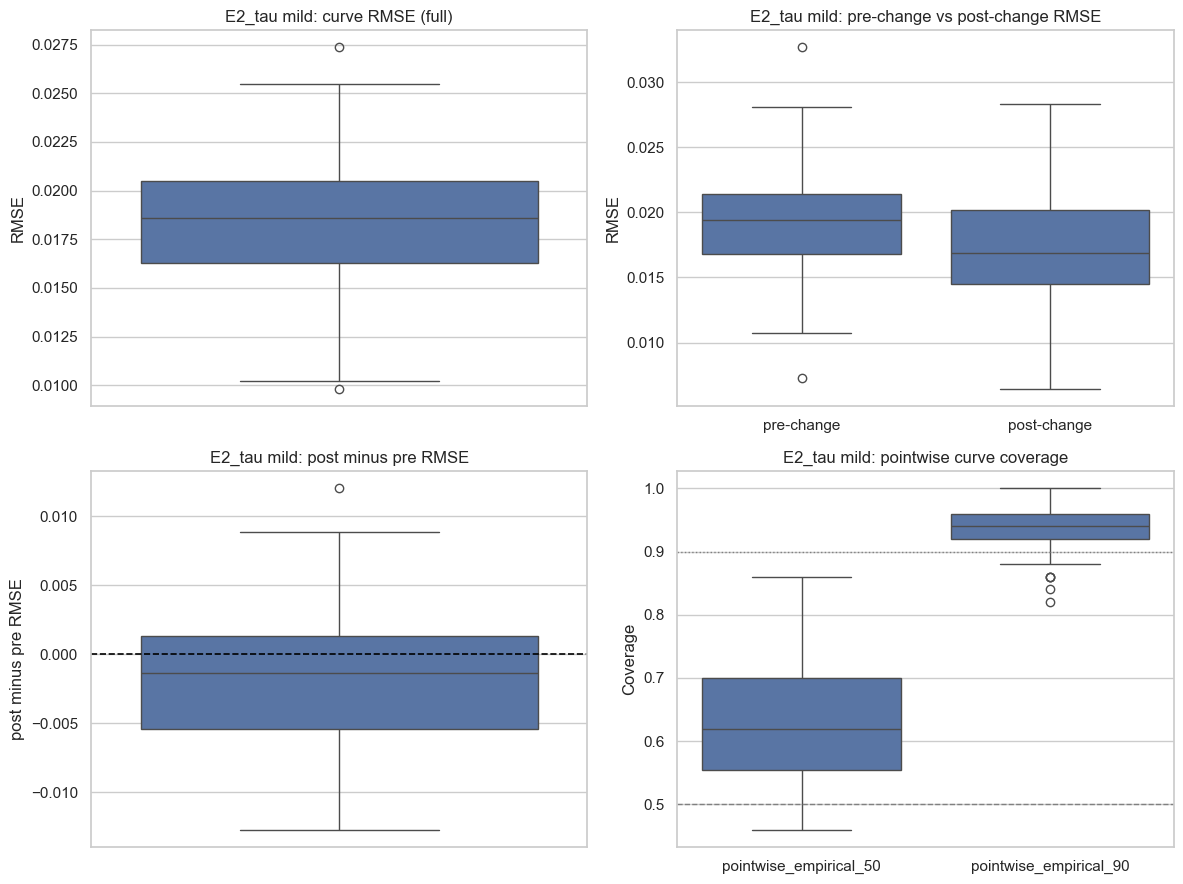

In [36]:
plot_curve_level_ppc_summary(
    curve_tau_outputs["mild"]["case_df"],
    severity_label="mild",
    experiment_label="E2_tau",
    out_dir=str(OUTPUTS_ROOT / "E2" / "curve_level_tau" / "mild"),
    split_mode="tau",
)


In [37]:
display(curve_tau_outputs["medium"]["summary_df"].round(4))
display(curve_tau_outputs["medium"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6354,0.1061,0.6300,0.4800,0.8400
1,pointwise_empirical_90,0.9302,0.0465,0.9400,0.8390,0.9800
2,curve_bias_full,-0.0023,0.0045,-0.0034,-0.0070,0.0078
3,curve_mae_full,0.0144,0.0042,0.0139,0.0082,0.0219
4,curve_rmse_full,0.0190,0.0048,0.0185,0.0124,0.0274
5,curve_bias_first,-0.0044,0.0050,-0.0038,-0.0135,0.0034
6,curve_mae_first,0.0155,0.0038,0.0158,0.0088,0.0210
7,curve_rmse_first,0.0194,0.0042,0.0196,0.0120,0.0271
8,curve_bias_second,-0.0012,0.0072,-0.0030,-0.0094,0.0165
9,curve_mae_second,0.0135,0.0056,0.0121,0.0077,0.0252


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,true_beta_timeavg,true_beta_infweighted,true_R0_timeavg,true_R0_infweighted,beta_ref_mode,beta0,gamma,tau,kappa,severity
0,0,0.76,0.98,-0.0063,0.0117,0.0162,0.0001,0.0069,0.0080,-0.0097,...,0.2081,0.2495,0.6157,0.7383,time_avg,0.2610,0.3380,17,0.6926,medium
1,1,0.44,0.82,0.0067,0.0235,0.0289,-0.0060,0.0179,0.0210,0.0126,...,0.2980,0.2827,3.1786,3.0153,time_avg,0.3843,0.0938,16,0.6699,medium
2,2,0.84,0.98,-0.0031,0.0078,0.0120,-0.0037,0.0099,0.0163,-0.0028,...,0.2359,0.2721,0.5566,0.6421,time_avg,0.2754,0.4238,17,0.7828,medium
3,3,0.60,0.88,-0.0034,0.0147,0.0198,-0.0056,0.0153,0.0208,-0.0019,...,0.4358,0.4603,2.0888,2.2062,time_avg,0.5088,0.2087,20,0.7609,medium
4,4,0.72,0.98,-0.0083,0.0112,0.0154,-0.0095,0.0137,0.0189,-0.0075,...,0.1393,0.1578,0.7450,0.8441,time_avg,0.1825,0.1870,20,0.6053,medium


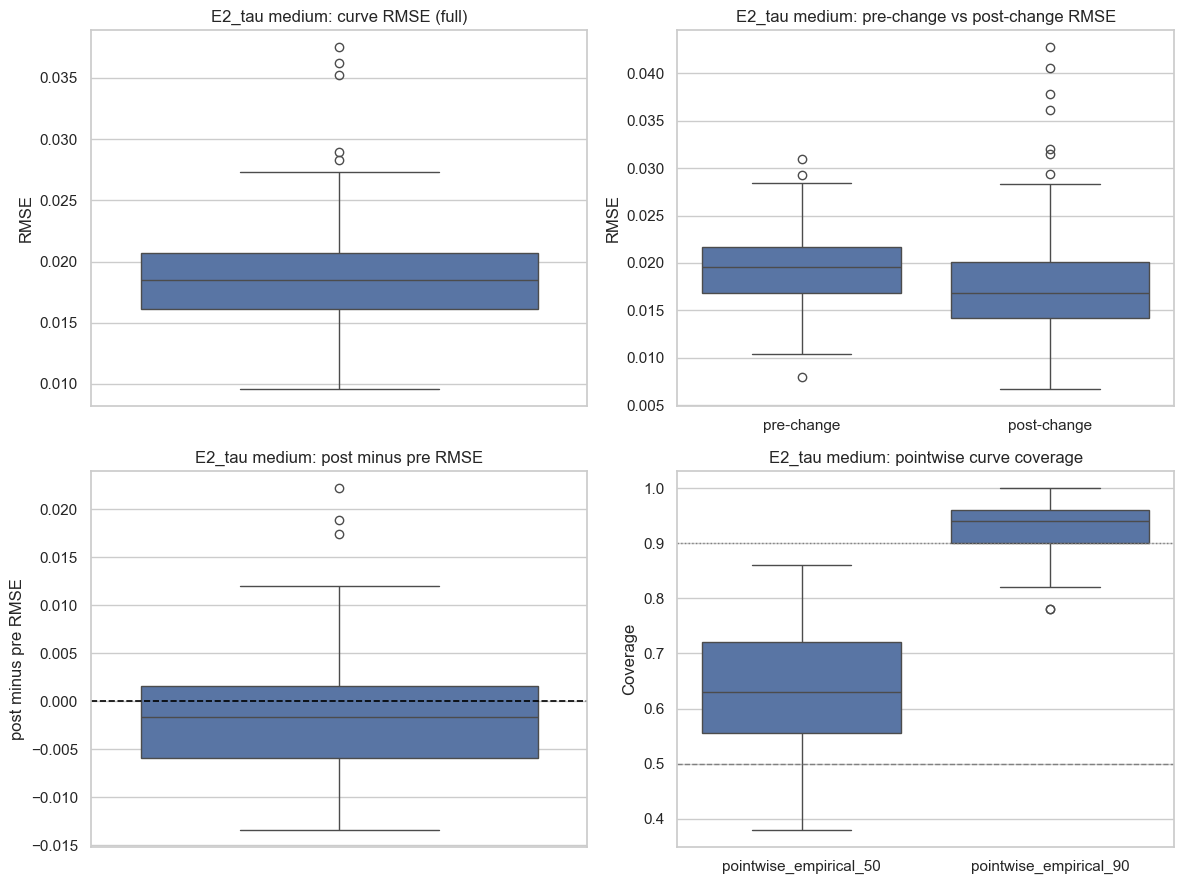

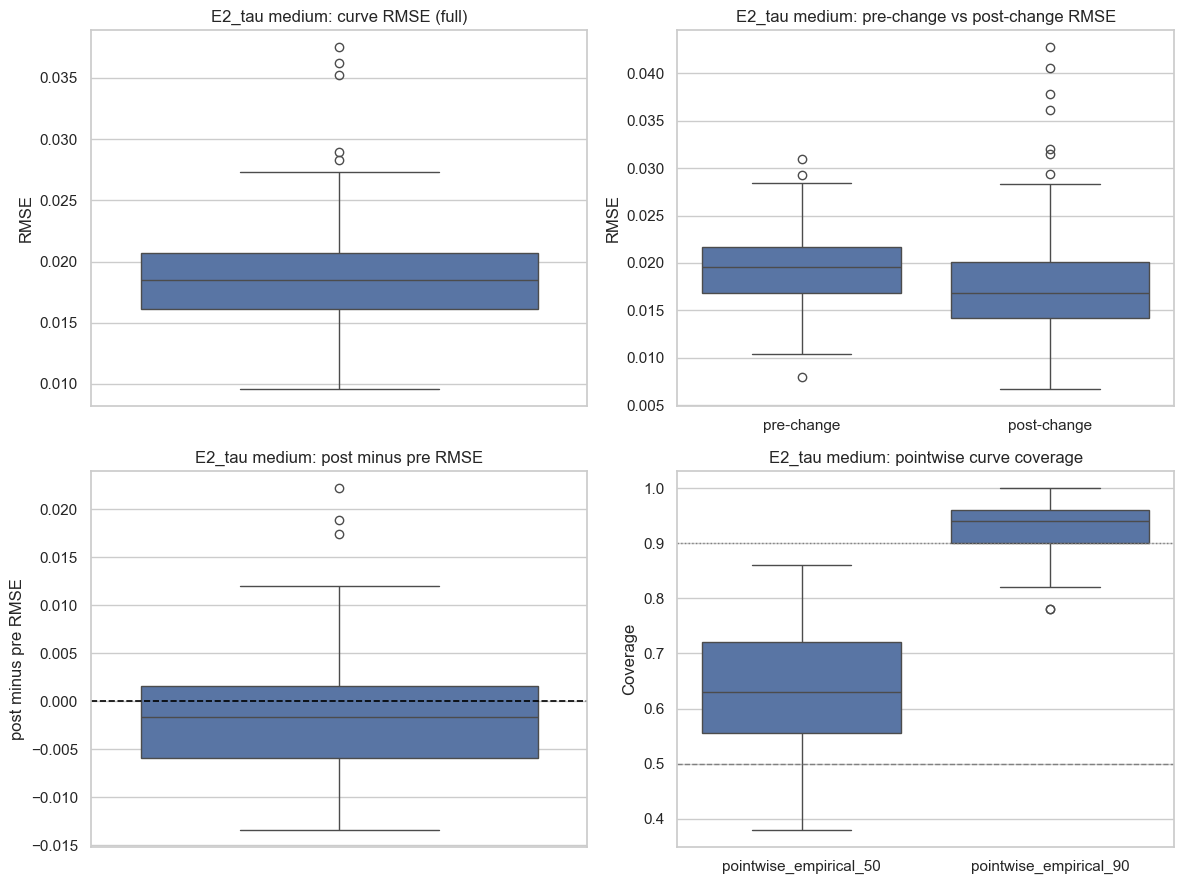

In [38]:
plot_curve_level_ppc_summary(
    curve_tau_outputs["medium"]["case_df"],
    severity_label="medium",
    experiment_label="E2_tau",
    out_dir=str(OUTPUTS_ROOT / "E2" / "curve_level_tau" / "medium"),
    split_mode="tau",
)


In [39]:
display(curve_tau_outputs["strong"]["summary_df"].round(4))
display(curve_tau_outputs["strong"]["case_df"].head().round(4))


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6260,0.1227,0.6200,0.4380,0.8200
1,pointwise_empirical_90,0.9168,0.0743,0.9400,0.8150,0.9800
2,curve_bias_full,-0.0021,0.0050,-0.0034,-0.0066,0.0084
3,curve_mae_full,0.0149,0.0059,0.0138,0.0081,0.0269
4,curve_rmse_full,0.0198,0.0071,0.0185,0.0127,0.0351
5,curve_bias_first,-0.0050,0.0051,-0.0047,-0.0132,0.0035
6,curve_mae_first,0.0159,0.0039,0.0162,0.0088,0.0230
7,curve_rmse_first,0.0201,0.0044,0.0202,0.0124,0.0277
8,curve_bias_second,-0.0006,0.0076,-0.0024,-0.0083,0.0153
9,curve_mae_second,0.0139,0.0079,0.0119,0.0072,0.0310


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_first,curve_mae_first,curve_rmse_first,curve_bias_second,...,true_beta_timeavg,true_beta_infweighted,true_R0_timeavg,true_R0_infweighted,beta_ref_mode,beta0,gamma,tau,kappa,severity
0,0,0.76,0.96,-0.0063,0.0114,0.0161,-0.0001,0.0068,0.0082,-0.0095,...,0.1596,0.2444,0.4722,0.7231,time_avg,0.2610,0.3380,17,0.4112,strong
1,1,0.32,0.72,0.0084,0.0291,0.0362,-0.0062,0.0177,0.0213,0.0153,...,0.2233,0.2016,2.3814,2.1499,time_avg,0.3843,0.0938,16,0.3839,strong
2,2,0.84,0.98,-0.0031,0.0080,0.0124,-0.0039,0.0104,0.0170,-0.0027,...,0.1880,0.2697,0.4436,0.6363,time_avg,0.2754,0.4238,17,0.5194,strong
3,3,0.54,0.86,-0.0035,0.0159,0.0215,-0.0081,0.0180,0.0236,-0.0004,...,0.3541,0.4144,1.6969,1.9862,time_avg,0.5088,0.2087,20,0.4931,strong
4,4,0.78,0.98,-0.0051,0.0099,0.0137,-0.0067,0.0125,0.0176,-0.0040,...,0.1066,0.1496,0.5699,0.7999,time_avg,0.1825,0.1870,20,0.3064,strong


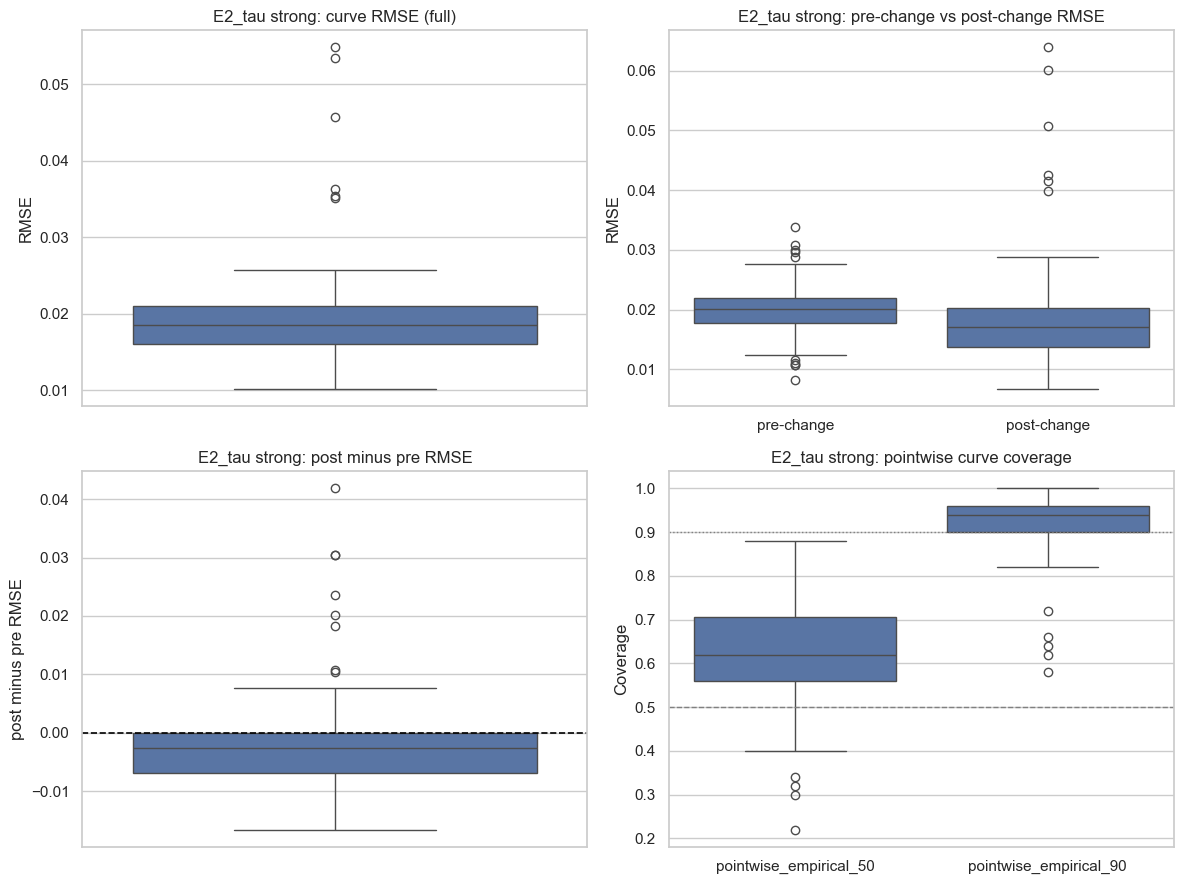

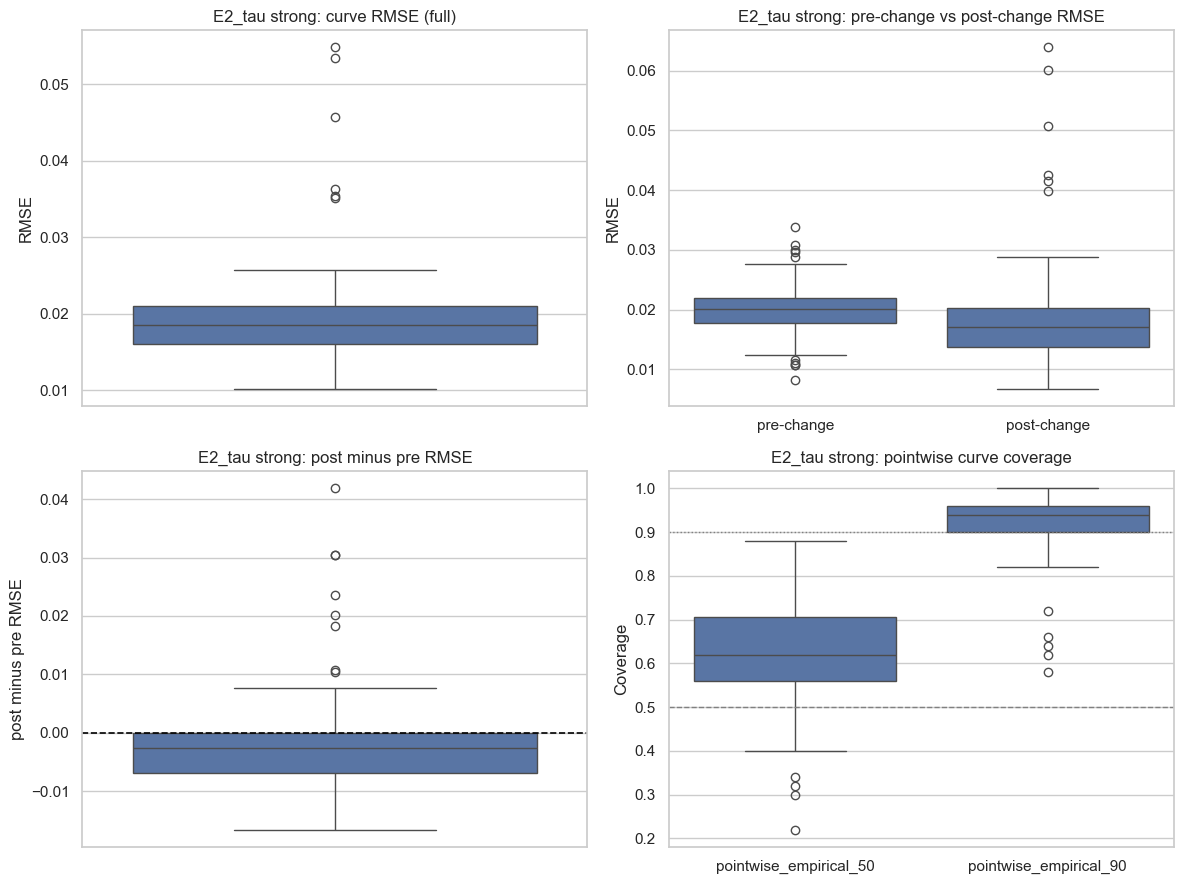

In [40]:
plot_curve_level_ppc_summary(
    curve_tau_outputs["strong"]["case_df"],
    severity_label="strong",
    experiment_label="E2_tau",
    out_dir=str(OUTPUTS_ROOT / "E2" / "curve_level_tau" / "strong"),
    split_mode="tau",
)
